# 2. Preliminaries

To prepare for your dive into deep learning, you will need a few survival skills: (i) techniques for storing and manipulating data; (ii) libraries for ingesting and preprocessing data from a variety of sources; (iii) knowledge of the basic linear algebraic operations that we apply to high-dimensional data elements; (iv) just enough calculus to determine which direction to adjust each parameter in order to decrease the loss function; (v) the ability to automatically compute derivatives so that you can forget much of the calculus you just learned; (vi) some basic fluency in probability, our primary language for reasoning under uncertainty; and (vii) some aptitude for finding answers in the official documentation when you get stuck.

In short, this chapter provides a rapid introduction to the basics that you will need to follow most of the technical content in this book.

## 2.1. Data Manipulation

In order to get anything done, we need some way to store and manipulate data. Generally, there are two important things we need to do with data: (i) acquire them; and (ii) process them once they are inside the computer. There is no point in acquiring data without some way to store it, so to start, let's get our hands dirty with $n$-dimensional arrays, which we also call *tensors*. If you already know the NumPy scientific computing package, this will be a breeze. For all modern deep learning frameworks, the *tensor class* (`ndarray` in MXNet, `Tensor` in PyTorch and TensorFlow) resembles NumPy's `ndarray`, with a few killer features added. First, the tensor class supports automatic differentiation. Second, it leverages GPUs to accelerate numerical computation, whereas NumPy only runs on CPUs. These properties make neural networks both easy to code and fast to run.

### 2.1.1. Getting Started

In the one-dimensional case, i.e., when only one axis is needed for the data, a tensor is called a *vector*. With two axes, a tensor is called a *matrix*. With $k > 2$ axes, we drop the specialized names and just refer to the object as a $k^\textrm{th}$-*order tensor*.

PyTorch provides a variety of functions for creating new tensors prepopulated with values. For example, by invoking `arange(n)`, we can create a vector of evenly spaced values, starting at 0 (included) and ending at `n` (not included). By default, the interval size is $1$. Unless otherwise specified, new tensors are stored in main memory and designated for CPU-based computation.

In [1]:
import torch

x = torch.arange(12, dtype=torch.float32)
x

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

Each of these values is called an *element* of the tensor. The tensor `x` contains 12 elements. We can inspect the total number of elements in a tensor via its `numel` method.

In [14]:
x.numel()

12

We can access a tensor's *shape* (the length along each axis) by inspecting its `shape` attribute. Because we are dealing with a vector here, the `shape` contains just a single element and is identical to the size.

In [15]:
x.shape

torch.Size([12])

We can change the shape of a tensor without altering its size or values, by invoking `reshape`. For example, we can transform our vector `x` whose shape is (12,) to a matrix `X`  with shape (3, 4). This new tensor retains all elements but reconfigures them into a matrix. Notice that the elements of our vector are laid out one row at a time and thus `x[3] == X[0, 3]`.

In [16]:
X = x.reshape(3, 4)
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

Note that specifying every shape component to `reshape` is redundant. Because we already know our tensor's size, we can work out one component of the shape given the rest. For example, given a tensor of size $n$ and target shape ($h$, $w$), we know that $w = n/h$. To automatically infer one component of the shape, we can place a `-1` for the shape component that should be inferred automatically. In our case, instead of calling `x.reshape(3, 4)`, we could have equivalently called `x.reshape(-1, 4)` or `x.reshape(3, -1)`.

Practitioners often need to work with tensors initialized to contain all 0s or 1s. We can construct a tensor with all elements set to 0 and a shape of (2, 3, 4) via the `zeros` function.

In [17]:
torch.zeros((2, 3, 4))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

Similarly, we can create a tensor with all 1s by invoking `ones`.

In [18]:
torch.ones((2, 3, 4))

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

We often wish to sample each element randomly (and independently) from a given probability distribution. For example, the parameters of neural networks are often initialized randomly. The following snippet creates a tensor with elements drawn from a standard Gaussian (normal) distribution with mean 0 and standard deviation 1.

In [19]:
torch.randn(3, 4)

tensor([[-0.3838, -1.1303, -0.2048, -0.0698],
        [ 0.8497,  1.1495,  0.7540,  0.0935],
        [ 2.8626, -0.2025, -0.5376, -0.7671]])

Finally, we can construct tensors by supplying the exact values for each element by supplying (possibly nested) Python list(s) containing numerical literals. Here, we construct a matrix with a list of lists, **where the outermost list corresponds to axis 0**, and the inner list corresponds to axis 1.

In [20]:
torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])

### 2.1.2. Indexing and Slicing

As with  Python lists, we can access tensor elements by indexing (starting with 0). To access an element based on its position relative to the end of the list, we can use negative indexing. Finally, we can access whole ranges of indices via slicing (e.g., `X[start:stop]`), where the returned value includes the first index (`start`) *but not the last* (`stop`). Finally, when only one index (or slice) is specified for a $k^\textrm{th}$-order tensor, it is applied along axis 0. Thus, in the following code, `[-1]` selects the last row and `[1:3]` selects the second and third rows.

In [21]:
X[-1], X[1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

Beyond reading them, we can also *write* elements of a matrix by specifying indices.

In [22]:
X[1, 2] = 17
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5., 17.,  7.],
        [ 8.,  9., 10., 11.]])

If we want to assign multiple elements the same value, we apply the indexing on the left-hand side of the assignment operation. For instance, `[:2, :]`  accesses the first and second rows, where `:` takes all the elements along axis 1 (column). While we discussed indexing for matrices, this also works for vectors and for tensors of more than two dimensions.

In [23]:
X[:2, :] = 12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

### 2.1.3. Operations

Now that we know how to construct tensors and how to read from and write to their elements, we can begin to manipulate them with various mathematical operations. Among the most useful of these are the *elementwise* operations. These apply a standard scalar operation to each element of a tensor. For functions that take two tensors as inputs, elementwise operations apply some standard binary operator on each pair of corresponding elements. We can create an elementwise function from any function that maps from a scalar to a scalar.

In mathematical notation, we denote such *unary* scalar operators (taking one input) by the signature $f: \mathbb{R} \rightarrow \mathbb{R}$. This just means that the function maps from any real number onto some other real number. Most standard operators, including unary ones like $e^x$, can be applied elementwise.

In [ ]:
torch.exp(x)

tensor([162754.7969, 162754.7969, 162754.7969, 162754.7969, 162754.7969,
        162754.7969, 162754.7969, 162754.7969,   2980.9580,   8103.0840,
         22026.4648,  59874.1406])

Likewise, we denote *binary* scalar operators, which map pairs of real numbers to a (single) real number via the signature $f: \mathbb{R}, \mathbb{R} \rightarrow \mathbb{R}$. Given any two vectors $\mathbf{u}$ and $\mathbf{v}$ *of the same shape*, and a binary operator $f$, we can produce a vector $\mathbf{c} = F(\mathbf{u},\mathbf{v})$ by setting $c_i \gets f(u_i, v_i)$ for all $i$, where $c_i, u_i$, and $v_i$ are the $i^\textrm{th}$ elements of vectors $\mathbf{c}, \mathbf{u}$, and $\mathbf{v}$. Here, we produced the vector-valued $F: \mathbb{R}^d, \mathbb{R}^d \rightarrow \mathbb{R}^d$ by *lifting* the scalar function to an elementwise vector operation. The common standard arithmetic operators for addition (`+`), subtraction (`-`), multiplication (`*`), division (`/`), and exponentiation (`**`) have all been *lifted* to elementwise operations for identically-shaped tensors of arbitrary shape.

In [ ]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x ** y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In addition to elementwise computations, we can also perform linear algebraic operations, such as dot products and matrix multiplications. We will elaborate on these in Section 2.3.

We can also *concatenate* multiple tensors, stacking them end-to-end to form a larger one. We just need to provide a list of tensors and tell the system along which axis to concatenate. The example below shows what happens when we concatenate two matrices along rows (axis 0) instead of columns (axis 1). We can see that the first output's axis-0 length ($6$) is the sum of the two input tensors' axis-0 lengths ($3 + 3$); while the second output's axis-1 length ($8$) is the sum of the two input tensors' axis-1 lengths ($4 + 4$).

In [9]:
import torch

X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [10]:
torch.stack((X, Y), dim=0), torch.stack((X, Y), dim=1), torch.stack((X, Y), dim=2)

(tensor([[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]],
 
         [[ 2.,  1.,  4.,  3.],
          [ 1.,  2.,  3.,  4.],
          [ 4.,  3.,  2.,  1.]]]),
 tensor([[[ 0.,  1.,  2.,  3.],
          [ 2.,  1.,  4.,  3.]],
 
         [[ 4.,  5.,  6.,  7.],
          [ 1.,  2.,  3.,  4.]],
 
         [[ 8.,  9., 10., 11.],
          [ 4.,  3.,  2.,  1.]]]),
 tensor([[[ 0.,  2.],
          [ 1.,  1.],
          [ 2.,  4.],
          [ 3.,  3.]],
 
         [[ 4.,  1.],
          [ 5.,  2.],
          [ 6.,  3.],
          [ 7.,  4.]],
 
         [[ 8.,  4.],
          [ 9.,  3.],
          [10.,  2.],
          [11.,  1.]]]))

Sometimes, we want to construct a binary tensor via *logical statements*. Take `X == Y` as an example. For each position `i, j`, if `X[i, j]` and `Y[i, j]` are equal, then the corresponding entry in the result takes value `True`, otherwise it takes value `False`.

In [ ]:
X == Y

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

Summing all the elements in the tensor yields a tensor with only one element.

In [ ]:
X.sum()

tensor(66.)

### 2.1.4. Broadcasting

By now, you know how to perform elementwise binary operations on two tensors of the same shape. Under certain conditions, even when shapes differ, we can still perform elementwise binary operations by invoking the *broadcasting mechanism*. Broadcasting works according to the following two-step procedure: (i) expand one or both arrays by copying elements along axes with length 1 so that after this transformation, the two tensors have the same shape; (ii) perform an elementwise operation on the resulting arrays.

In [ ]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

Since `a` and `b` are $3\times1$ and $1\times2$ matrices, respectively, their shapes do not match up. Broadcasting produces a larger $3\times2$ matrix by replicating matrix `a` along the columns and matrix `b` along the rows before adding them elementwise.

In [ ]:
a + b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

### 2.1.5. Saving Memory

Running operations can cause new memory to be allocated to host results. For example, if we write `Y = X + Y`, we dereference the tensor that `Y` used to point to and instead point `Y` at the newly allocated memory. We can demonstrate this issue with Python's `id()` function, which gives us the exact address of the referenced object in memory. Note that after we run `Y = Y + X`, `id(Y)` points to a different location. That is because Python first evaluates `Y + X`, allocating new memory for the result and then points `Y` to this new location in memory.

In [ ]:
before = id(Y)
Y = Y + X
id(Y) == before

False

This might be undesirable for two reasons. First, we do not want to run around allocating memory unnecessarily all the time. In machine learning, we often have hundreds of megabytes of parameters and update all of them multiple times per second. Whenever possible, we want to perform these updates *in place*. Second, we might point at the same parameters from multiple variables. If we do not update in place, we must be careful to update all of these references, lest we spring a memory leak or inadvertently refer to stale parameters.

Fortunately, performing in-place operations is easy. We can assign the result of an operation to a previously allocated array `Y` by using slice notation: `Y[:] = <expression>`. To illustrate this concept, we overwrite the values of tensor `Z`, after initializing it, using `zeros_like`, to have the same shape as `Y`.

In [ ]:
Z = torch.zeros_like(Y)
print('id(Z):', id(Z))
Z[:] = X + Y
print('id(Z):', id(Z))

id(Z): 128319694201216
id(Z): 128319694201216


If the value of `X` is not reused in subsequent computations, we can also use `X[:] = X + Y` or `X += Y` to reduce the memory overhead of the operation.

In [ ]:
before = id(X)
X += Y
id(X) == before

True

### 2.1.6. Conversion to Other Python Objects

Converting to a NumPy tensor (`ndarray`), or vice versa, is easy. The torch tensor and NumPy array will share their underlying memory, and changing one through an in-place operation will also change the other.

In [ ]:
A = X.numpy()
B = torch.tensor(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

To convert a size-1 tensor to a Python scalar, we can invoke the `item` function or Python's built-in functions.

In [ ]:
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

### 2.1.7. Summary

The tensor class is the main interface for storing and manipulating data in deep learning libraries. Tensors provide a variety of functionalities including construction routines; indexing and slicing; basic mathematics operations; broadcasting; memory-efficient assignment; and conversion to and from other Python objects.

### 2.1.8. Exercises

1. Run the code in this section. Change the conditional statement `X == Y` to `X < Y` or `X > Y`, and then see what kind of tensor you can get.

1. Replace the two tensors that operate by element in the broadcasting mechanism with other shapes, e.g., 3-dimensional tensors. Is the result the same as expected?

## 2.2. Data Preprocessing

So far, we have been working with synthetic data that arrived in ready-made tensors. However, to apply deep learning in the wild we must extract messy data stored in arbitrary formats, and preprocess it to suit our needs. Fortunately, the *pandas* [library](https://pandas.pydata.org/) can do much of the heavy lifting. This section, while no substitute for a proper *pandas* [tutorial](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html), will give you a crash course on some of the most common routines.

### 2.2.1. Reading the Dataset

Comma-separated values (CSV) files are ubiquitous for the storing of tabular (spreadsheet-like) data. In them, each line corresponds to one record and consists of several (comma-separated) fields, e.g., "Albert Einstein,March 14 1879,Ulm,Federal polytechnic school,field of gravitational physics". To demonstrate how to load CSV files with `pandas`, we create a CSV file below `../data/house_tiny.csv`. This file represents a dataset of homes, where each row corresponds to a distinct home and the columns correspond to the number of rooms (`NumRooms`), the roof type (`RoofType`), and the price (`Price`).

In [11]:
import os

os.makedirs(os.path.join('.', 'data'), exist_ok=True)
data_file = os.path.join('.', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('''NumRooms,RoofType,Price
NA,NA,127500
2,NA,106000
4,Slate,178100
NA,NA,140000''')

Now let's import `pandas` and load the dataset with `read_csv`.

In [12]:
import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms RoofType   Price
0       NaN      NaN  127500
1       2.0      NaN  106000
2       4.0    Slate  178100
3       NaN      NaN  140000


### 2.2.2. Data Preparation

In supervised learning, we train models to predict a designated *target* value, given some set of *input* values. Our first step in processing the dataset is to separate out columns corresponding to input versus target values. We can select columns either by name or via integer-location based indexing (`iloc`).

You might have noticed that `pandas` replaced all CSV entries with value `NA` with a special `NaN` (*not a number*) value. This can also happen whenever an entry is empty, e.g., "3,,,270000". These are called *missing values* and they are the "bed bugs" of data science, a persistent menace that you will confront throughout your career. Depending upon the context, missing values might be handled either via *imputation* or *deletion*. Imputation replaces missing values with estimates of their values while deletion simply discards either those rows or those columns that contain missing values.

Here are some common imputation heuristics. For categorical input fields, we can treat `NaN` as a category. Since the `RoofType` column takes values `Slate` and `NaN`, `pandas` can convert this column into two columns `RoofType_Slate` and `RoofType_nan`. A row whose roof type is `Slate` will set values of `RoofType_Slate` and `RoofType_nan` to 1 and 0, respectively. The converse holds for a row with a missing `RoofType` value.

In [19]:
inputs, targets = data.iloc[:, 0:2], data.iloc[:, 2]
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)

   NumRooms  RoofType_Slate  RoofType_nan
0       NaN           False          True
1       2.0           False          True
2       4.0            True         False
3       NaN           False          True


For missing numerical values, one common heuristic is to replace the `NaN` entries with the mean value of the corresponding column.

In [20]:
inputs = inputs.fillna(inputs.mean())
print(inputs)

   NumRooms  RoofType_Slate  RoofType_nan
0       3.0           False          True
1       2.0           False          True
2       4.0            True         False
3       3.0           False          True


### 2.2.3. Conversion to the Tensor Format

Now that all the entries in `inputs` and `targets` are numerical, we can load them into a tensor (recall Section 2.1).

In [ ]:
import torch

X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(targets.to_numpy(dtype=float))
X, y

(tensor([[3., 0., 1.],
         [2., 0., 1.],
         [4., 1., 0.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

### 2.2.4. Discussion

You now know how to partition data columns, impute missing variables, and load `pandas` data into tensors. In Section 5.7, you will pick up some more data processing skills. While this crash course kept things simple, data processing can get hairy. For example, rather than arriving in a single CSV file, our dataset might be spread across multiple files extracted from a relational database. For instance, in an e-commerce application, customer addresses might live in one table and purchase data in another. Moreover, practitioners face myriad data types beyond categorical and numeric, for example, text strings, images, audio data, and point clouds. Oftentimes, advanced tools and efficient algorithms are required in order to prevent data processing from becoming the biggest bottleneck in the machine learning pipeline. These problems will arise when we get to computer vision and natural language processing. Finally, we must pay attention to data quality. Real-world datasets are often plagued by outliers, faulty measurements from sensors, and recording errors, which must be addressed before feeding the data into any model. Data visualization tools such as [seaborn](https://seaborn.pydata.org/), [Bokeh](https://docs.bokeh.org/), or [matplotlib](https://matplotlib.org/) can help you to manually inspect the data and develop intuitions about the type of problems you may need to address.

### 2.2.5. Exercises

1. Try loading datasets, e.g., Abalone from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets.php) and inspect their properties. What fraction of them has missing values? What fraction of the variables is numerical, categorical, or text?

1. Try indexing and selecting data columns by name rather than by column number. The pandas documentation on [indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html) has further details on how to do this.

1. How large a dataset do you think you could load this way? What might be the limitations? Hint: consider the time to read the data, representation, processing, and memory footprint. Try this out on your laptop. What happens if you try it out on a server?

1. How would you deal with data that has a very large number of categories? What if the category labels are all unique? Should you include the latter?

1. What alternatives to pandas can you think of? How about [loading NumPy tensors from a file](https://numpy.org/doc/stable/reference/generated/numpy.load.html)? Check out [Pillow](https://python-pillow.org/), the Python Imaging Library.

## 2.3. Linear Algebra

By now, we can load datasets into tensors and manipulate these tensors with basic mathematical operations. To start building sophisticated models, we will also need a few tools from linear algebra. This section offers a gentle introduction to the most essential concepts, starting from scalar arithmetic and ramping up to matrix multiplication.

### 2.3.1. Scalars

Most everyday mathematics consists of manipulating numbers one at a time. Formally, we call these values *scalars*. ...

We denote scalars by ordinary lower-cased letters (e.g., $x$, $y$, and $z$) and the space of all (continuous) *real-valued* scalars by $\mathbb{R}$. For expedience, we will skip past rigorous definitions of *spaces*: just remember that the expression $x \in \mathbb{R}$ is a formal way to say that $x$ is a real-valued scalar. The symbol $\in$ (pronounced "in") denotes membership in a set. For example, $x, y \in \{0, 1\}$ indicates that $x$ and $y$ are variables that can only take values $0$ or $1$.

Scalars are implemented as tensors that contain only one element. Below, we assign two scalars and perform the familiar addition, multiplication, division, and exponentiation operations.

In [ ]:
x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

### 2.3.2. Vectors

For current purposes, you can think of a vector as a fixed-length array of scalars. As with their code counterparts, we call these scalars the *elements* of the vector (synonyms include *entries* and *components*). When vectors represent examples from real-world datasets, their values hold some real-world significance. ... We denote vectors by bold lowercase letters, (e.g., $\mathbf{x}$, $\mathbf{y}$, and $\mathbf{z}$).

Vectors are implemented as $1^{\textrm{st}}$-order tensors. In general, such tensors can have arbitrary lengths, subject to memory limitations. Caution: in Python, as in most programming languages, vector indices start at $0$, also known as *zero-based indexing*, whereas in linear algebra subscripts begin at $1$ (one-based indexing).

In [ ]:
x = torch.arange(3)
x

tensor([0, 1, 2])

We can refer to an element of a vector by using a subscript. For example, $x_2$ denotes the second element of $\mathbf{x}$. Since $x_2$ is a scalar, we do not bold it. By default, we visualize vectors by stacking their elements vertically.

$$\mathbf{x} =\begin{bmatrix}x_{1}  \\ \vdots  \\x_{n}\end{bmatrix}, \tag{2.3.1}$$

Here $x_1, \ldots, x_n$ are elements of the vector. Later on, we will distinguish between such *column vectors* and *row vectors* whose elements are stacked horizontally. Recall that we access a tensor's elements via indexing.

In [ ]:
x[2]

tensor(2)

To indicate that a vector contains $n$ elements, we write $\mathbf{x} \in \mathbb{R}^n$. Formally, we call $n$ the *dimensionality* of the vector. In code, this corresponds to the tensor's length, accessible via Python's built-in `len` function.

In [ ]:
len(x)

3

We can also access the length via the `shape` attribute. The shape is a tuple that indicates a tensor's length along each axis. Tensors with just one axis have shapes with just one element.

In [ ]:
x.shape

torch.Size([3])

Oftentimes, the word “dimension” gets overloaded to mean both the number of axes and the length along a particular axis. To avoid this confusion, we use ***order*** to refer to the number of axes and ***dimensionality*** exclusively to refer to the number of components.

### 2.3.3. Matrices

Just as scalars are $0^{\textrm{th}}$-order tensors and vectors are $1^{\textrm{st}}$-order tensors, matrices are $2^{\textrm{nd}}$-order tensors. We denote matrices by bold capital letters (e.g., $\mathbf{X}$, $\mathbf{Y}$, and $\mathbf{Z}$), and represent them in code by tensors with two axes. The expression $\mathbf{A} \in \mathbb{R}^{m \times n}$ indicates that a matrix $\mathbf{A}$ contains $m \times n$ real-valued scalars, arranged as $m$ rows and $n$ columns. When $m = n$, we say that a matrix is *square*. Visually, we can illustrate any matrix as a table. To refer to an individual element, we subscript both the row and column indices, e.g., $a_{ij}$ is the value that belongs to $\mathbf{A}$'s $i^{\textrm{th}}$ row and $j^{\textrm{th}}$ column:

$$\mathbf{A}=\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \\ \end{bmatrix}. \tag{2.3.2}$$

In code, we represent a matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ by a $2^{\textrm{nd}}$-order tensor with shape ($m$, $n$). We can convert any appropriately sized $m \times n$ tensor into an $m \times n$ matrix by passing the desired shape to `reshape`:

In [ ]:
A = torch.arange(6).reshape(3, 2)
A

tensor([[0, 1],
        [2, 3],
        [4, 5]])

Sometimes we want to flip the axes. When we exchange a matrix's rows and columns, the result is called its *transpose*. Formally, we signify a matrix $\mathbf{A}$'s transpose by $\mathbf{A}^\top$ and if $\mathbf{B} = \mathbf{A}^\top$, then $b_{ij} = a_{ji}$ for all $i$ and $j$. Thus, the transpose of an $m \times n$ matrix is an $n \times m$ matrix:

$$
\mathbf{A}^\top =
\begin{bmatrix}
    a_{11} & a_{21} & \dots  & a_{m1} \\
    a_{12} & a_{22} & \dots  & a_{m2} \\
    \vdots & \vdots & \ddots  & \vdots \\
    a_{1n} & a_{2n} & \dots  & a_{mn}
\end{bmatrix}. \tag{2.3.3}
$$

In code, we can access any matrix's transpose as follows:

In [ ]:
A.T

tensor([[0, 2, 4],
        [1, 3, 5]])

Symmetric matrices are the subset of square matrices that are equal to their own transposes: $\mathbf{A} = \mathbf{A}^\top$. The following matrix is symmetric:

In [ ]:
A = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
print(A)
A == A.T

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])


tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

Matrices are useful for representing datasets. Typically, rows correspond to individual records and columns correspond to distinct attributes.

### 2.3.4. Tensors

While you can go far in your machine learning journey with only scalars, vectors, and matrices, eventually you may need to work with higher-order tensors. Tensors give us a generic way of describing extensions to $n^{\textrm{th}}$-order arrays. We call software objects of the *tensor class* "tensors" precisely because they too can have arbitrary numbers of axes. While it may be confusing to use the word *tensor* for both the mathematical object and its realization in code, our meaning should usually be clear from context. We denote general tensors by capital letters with a special font face (e.g., $\mathsf{X}$, $\mathsf{Y}$, and $\mathsf{Z}$) and their indexing mechanism (e.g., $x_{ijk}$ and $[\mathsf{X}]_{1, 2i-1, 3}$) follows naturally from that of matrices.

Tensors will become more important when we start working with images. Each image arrives as a $3^{\textrm{rd}}$-order tensor with axes corresponding to the height, width, and *channel*. At each spatial location, the intensities of each color (red, green, and blue) are stacked along the channel. Furthermore, a collection of images is represented in code by a $4^{\textrm{th}}$-order tensor, where distinct images are indexed along the first axis. Higher-order tensors are constructed, as were vectors and matrices, by growing the number of shape components.

In [ ]:
torch.arange(24).reshape(2, 3, 4)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

### 2.3.5. Basic Properties of Tensor Arithmetic

Scalars, vectors, matrices, and higher-order tensors all have some handy properties. For example, elementwise operations produce outputs that have the same shape as their operands.

In [4]:
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone()  # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

The elementwise product of two matrices is called their *Hadamard product* (denoted $\odot$). We can spell out the entries of the Hadamard product of two matrices $\mathbf{A}, \mathbf{B} \in \mathbb{R}^{m \times n}$:

$$
\mathbf{A} \odot \mathbf{B} =
\begin{bmatrix}
    a_{11}  b_{11} & a_{12}  b_{12} & \dots  & a_{1n}  b_{1n} \\
    a_{21}  b_{21} & a_{22}  b_{22} & \dots  & a_{2n}  b_{2n} \\
    \vdots & \vdots & \ddots & \vdots \\
    a_{m1}  b_{m1} & a_{m2}  b_{m2} & \dots  & a_{mn}  b_{mn}
\end{bmatrix}. \tag{2.3.4}
$$

In [ ]:
A * B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

Adding or multiplying a scalar and a tensor produces a result with the same shape as the original tensor. Here, each element of the tensor is added to (or multiplied by) the scalar.

In [ ]:
a = 2
X = torch.arange(24).reshape(2, 3, 4)
a + X, (a * X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

### 2.3.6. Reduction

Often, we wish to calculate the sum of a tensor's elements. To express the sum of the elements in a vector $\mathbf{x}$ of length $n$, we write $\sum_{i=1}^n x_i$. There is a simple function for it:

In [ ]:
x = torch.arange(3, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2.]), tensor(3.))

To express sums over the elements of tensors of arbitrary shape, we simply sum over all its axes. For example, the sum of the elements of an $m \times n$ matrix $\mathbf{A}$ could be written $\sum_{i=1}^{m} \sum_{j=1}^{n} a_{ij}$.

In [5]:
A, A.shape, A.sum()

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 torch.Size([2, 3]),
 tensor(15.))

By default, invoking the sum function *reduces* a tensor along all of its axes, eventually producing a scalar. Our libraries also allow us to specify the axes along which the tensor should be reduced. To sum over all elements along the rows (axis 0), we specify `axis=0` in `sum`. Since the input matrix reduces along axis 0 to generate the output vector, this axis is missing from the shape of the output.

In [6]:
A, A.shape, A.sum(axis=0), A.sum(axis=0).shape

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 torch.Size([2, 3]),
 tensor([3., 5., 7.]),
 torch.Size([3]))

Specifying `axis=1` will reduce the column dimension (axis 1) by summing up elements of all the columns.

---

牧之：`axis=0`，沿着 0 轴进行计算，把 0 轴压缩掉，保留了列数。

In [7]:
A.sum(axis=1), A.sum(axis=1).shape

(tensor([ 3., 12.]), torch.Size([2]))

Reducing a matrix along both rows and columns via summation is equivalent to summing up all the elements of the matrix.

In [8]:
A.sum(axis=[0, 1]) == A.sum()  # Same as A.sum()

tensor(True)

A related quantity is the *mean*, also called the *average*. We calculate the mean by dividing the sum by the total number of elements. Because computing the mean is so common, it gets a dedicated library function that works analogously to `sum`.

In [9]:
A.mean(), A.sum() / A.numel()

(tensor(2.5000), tensor(2.5000))

Likewise, the function for calculating the mean can also reduce a tensor along specific axes.

---
牧之：沿着目标轴相加，除以在目标轴的维度。

In [9]:
A, A.mean(axis=0), A.sum(axis=0) / A.shape[0]

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([1.5000, 2.5000, 3.5000]),
 tensor([1.5000, 2.5000, 3.5000]))

### 2.3.7. Non-Reduction Sum

Sometimes it can be useful to keep the number of axes unchanged when invoking the function for calculating the sum or mean. This matters when we want to use the broadcast mechanism.

---
牧之：目标轴保持，但维度会缩为 1，刚好适合广播机制。

In [10]:
print(A)
sum_A = A.sum(axis=1, keepdims=True)
sum_A, sum_A.shape

tensor([[0., 1., 2.],
        [3., 4., 5.]])


(tensor([[ 3.],
         [12.]]),
 torch.Size([2, 1]))

For instance, since `sum_A` keeps its two axes after summing each row, we can divide `A` by `sum_A` with broadcasting to create a matrix where each row sums up to $1$.

In [11]:
A / sum_A

tensor([[0.0000, 0.3333, 0.6667],
        [0.2500, 0.3333, 0.4167]])

If we want to calculate the cumulative sum of elements of `A` along some axis, say `axis=0` (row by row), we can call the `cumsum` function. By design, this function does not reduce the input tensor along any axis.

In [12]:
print(A)
A.cumsum(axis=0)

tensor([[0., 1., 2.],
        [3., 4., 5.]])


tensor([[0., 1., 2.],
        [3., 5., 7.]])

### 2.3.8. Dot Products

So far, we have only performed elementwise operations, sums, and averages. And if this was all we could do, linear algebra would not deserve its own section. Fortunately, this is where things get more interesting. One of the most fundamental operations is the dot product. Given two vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$, their *dot product* $\mathbf{x}^\top \mathbf{y}$ (also known as *inner product*, $\langle \mathbf{x}, \mathbf{y}  \rangle$) is a sum over the products of the elements at the same position: $\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^{d} x_i y_i$.

In [11]:
x = torch.arange(3, dtype = torch.float32)
y = torch.ones(3, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2.]), tensor([1., 1., 1.]), tensor(3.))

Equivalently, we can calculate the dot product of two vectors by performing an elementwise multiplication followed by a sum:

In [ ]:
torch.sum(x * y)

tensor(3.)

Dot products are useful in a wide range of contexts. For example, given some set of values, denoted by a vector $\mathbf{x}  \in \mathbb{R}^n$, and a set of weights, denoted by $\mathbf{w} \in \mathbb{R}^n$, the weighted sum of the values in $\mathbf{x}$ according to the weights $\mathbf{w}$ could be expressed as the dot product $\mathbf{x}^\top \mathbf{w}$. When the weights are nonnegative and sum to $1$, i.e., $\left(\sum_{i=1}^{n} {w_i} = 1\right)$, the dot product expresses a *weighted average*. After normalizing two vectors to have unit length, the dot products express the cosine of the angle between them. Later in this section, we will formally introduce this notion of *length*.

### 2.3.9. Matrix–Vector Products

Now that we know how to calculate dot products, we can begin to understand the *product* between an $m \times n$ matrix $\mathbf{A}$ and an $n$-dimensional vector $\mathbf{x}$. To start off, we visualize our matrix in terms of its row vectors

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix}, \tag{2.3.5}$$

where each $\mathbf{a}^\top_{i} \in \mathbb{R}^n$ is a row vector representing the $i^\textrm{th}$ row of the matrix $\mathbf{A}$.

The matrix--vector product $\mathbf{A}\mathbf{x}$ is simply a column vector of length $m$, whose $i^\textrm{th}$ element is the dot product
$\mathbf{a}^\top_i \mathbf{x}$:

$$
\mathbf{A}\mathbf{x}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix}\mathbf{x}
= \begin{bmatrix}
 \mathbf{a}^\top_{1} \mathbf{x}  \\
 \mathbf{a}^\top_{2} \mathbf{x} \\
\vdots\\
 \mathbf{a}^\top_{m} \mathbf{x}\\
\end{bmatrix}. \tag{2.3.6}
$$

We can think of multiplication with a matrix $\mathbf{A}\in \mathbb{R}^{m \times n}$ as a transformation that projects vectors from $\mathbb{R}^{n}$ to $\mathbb{R}^{m}$. These transformations are remarkably useful. For example, we can represent rotations as multiplications by certain square matrices. Matrix--vector products also describe the key calculation involved in computing the outputs of each layer in a neural network given the outputs from the previous layer.

To express a matrix--vector product in code, we use the `mv` function.
Note that the column dimension of `A` (its length along axis 1) must be the same as the dimension of `x` (its length). Python has a convenience operator `@` that can execute both matrix--vector and matrix--matrix products (depending on its arguments). Thus we can write `A@x`.

In [12]:
print(A)
print(x)
A.shape, x.shape, torch.mv(A, x), A@x

tensor([[0., 1., 2.],
        [3., 4., 5.]])
tensor([0., 1., 2.])


(torch.Size([2, 3]), torch.Size([3]), tensor([ 5., 14.]), tensor([ 5., 14.]))

### 2.3.10. Matrix–Matrix Multiplication

Once you have gotten the hang of dot products and matrix--vector products, then *matrix--matrix multiplication* should be straightforward.

Say that we have two matrices $\mathbf{A} \in \mathbb{R}^{n \times k}$ and $\mathbf{B} \in \mathbb{R}^{k \times m}$:

$$\mathbf{A}=\begin{bmatrix}
 a_{11} & a_{12} & \cdots & a_{1k} \\
 a_{21} & a_{22} & \cdots & a_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
 a_{n1} & a_{n2} & \cdots & a_{nk} \\
\end{bmatrix},\quad
\mathbf{B}=\begin{bmatrix}
 b_{11} & b_{12} & \cdots & b_{1m} \\
 b_{21} & b_{22} & \cdots & b_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
 b_{k1} & b_{k2} & \cdots & b_{km} \\
\end{bmatrix}. \tag{2.3.7}$$

Let $\mathbf{a}^\top_{i} \in \mathbb{R}^k$ denote the row vector representing the $i^\textrm{th}$ row of the matrix $\mathbf{A}$ and let $\mathbf{b}_{j} \in \mathbb{R}^k$ denote the column vector from the $j^\textrm{th}$ column of the matrix $\mathbf{B}$:

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix},
\quad \mathbf{B}=\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}. \tag{2.3.8}
$$

To form the matrix product $\mathbf{C} \in \mathbb{R}^{n \times m}$, we simply compute each element $c_{ij}$ as the dot product between the $i^{\textrm{th}}$ row of $\mathbf{A}$ and the $j^{\textrm{th}}$ column of $\mathbf{B}$, i.e., $\mathbf{a}^\top_i \mathbf{b}_j$:

$$\mathbf{C} = \mathbf{AB} = \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix}
\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \mathbf{b}_1 & \mathbf{a}^\top_{1}\mathbf{b}_2& \cdots & \mathbf{a}^\top_{1} \mathbf{b}_m \\
 \mathbf{a}^\top_{2}\mathbf{b}_1 & \mathbf{a}^\top_{2} \mathbf{b}_2 & \cdots & \mathbf{a}^\top_{2} \mathbf{b}_m \\
 \vdots & \vdots & \ddots &\vdots\\
\mathbf{a}^\top_{n} \mathbf{b}_1 & \mathbf{a}^\top_{n}\mathbf{b}_2& \cdots& \mathbf{a}^\top_{n} \mathbf{b}_m
\end{bmatrix}. \tag{2.3.9}
$$

We can think of the matrix--matrix multiplication $\mathbf{AB}$ as performing $m$ matrix--vector products or $m \times n$ dot products and stitching the results together to form an $n \times m$ matrix. In the following snippet, we perform matrix multiplication on `A` and `B`. Here, `A` is a matrix with two rows and three columns, and `B` is a matrix with three rows and four columns. After multiplication, we obtain a matrix with two rows and four columns.

In [ ]:
B = torch.ones(3, 4)
torch.mm(A, B), A@B

(tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]))

The term *matrix--matrix multiplication* is often simplified to *matrix multiplication*, and should not be confused with the Hadamard product.

### 2.3.11. Norms

Some of the most useful operators in linear algebra are ***norms***. Informally, the norm of a vector tells us how *big* it is. For instance, the $\ell_2$ norm measures the (Euclidean) length of a vector. Here, we are employing a notion of ***size*** that concerns the magnitude of a vector's components (not its dimensionality).

A norm is a function $\| \cdot \|$ that maps a vector to a scalar and satisfies the following three properties:

1. Given any vector $\mathbf{x}$, if we scale (all elements of) the vector by a scalar $\alpha \in \mathbb{R}$, its norm scales accordingly: $$\|\alpha \mathbf{x}\| = |\alpha| \|\mathbf{x}\|. \tag{2.3.10}$$

1. For any vectors $\mathbf{x}$ and $\mathbf{y}$: norms satisfy the triangle inequality: $$\|\mathbf{x} + \mathbf{y}\| \leq \|\mathbf{x}\| + \|\mathbf{y}\|. \tag{2.3.11}$$

1. The norm of a vector is nonnegative and it only vanishes if the vector is zero: $$\|\mathbf{x}\| > 0 \textrm{ for all } \mathbf{x} \neq 0. \tag{2.3.12}$$

Many functions are valid norms and different norms encode different notions of size. The Euclidean norm that we all learned in elementary school geometry when calculating the hypotenuse of a right triangle is the square root of the sum of squares of a vector's elements. Formally, this is called the $\ell_2$ *norm* and expressed as

$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2}. \tag{2.3.13}$$

The method `norm` calculates the $\ell_2$ norm.

In [13]:
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

The $\ell_1$ norm is also common and the associated measure is called the Manhattan distance. By definition, the $\ell_1$ norm sums the absolute values of a vector's elements:

$$\|\mathbf{x}\|_1 = \sum_{i=1}^n \left|x_i \right|. \tag{2.3.14}$$

Compared to the $\ell_2$ norm, it is less sensitive to outliers. To compute the $\ell_1$ norm, we compose the absolute value with the sum operation.

In [14]:
torch.abs(u).sum()

tensor(7.)

Both the $\ell_2$ and $\ell_1$ norms are special cases of the more general $\ell_p$ *norms*:

$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^n \left|x_i \right|^p \right)^{1/p}. \tag{2.3.15}$$

In the case of matrices, matters are more complicated. After all, matrices can be viewed both as collections of individual entries *and* as objects that operate on vectors and transform them into other vectors. For instance, we can ask by how much longer the matrix--vector product $\mathbf{X} \mathbf{v}$ could be relative to $\mathbf{v}$. This line of thought leads to what is called the *spectral* norm. For now, we introduce the *Frobenius norm*, which is much easier to compute and defined as the square root of the sum of the squares of a matrix's elements:

$$\|\mathbf{X}\|_\textrm{F} = \sqrt{\sum_{i=1}^m \sum_{j=1}^n x_{ij}^2}. \tag{2.3.16}$$

The Frobenius norm behaves as if it were an $\ell_2$ norm of a matrix-shaped vector. Invoking the following function will calculate the Frobenius norm of a matrix.

In [15]:
torch.norm(torch.ones((4, 9)))

tensor(6.)

While we do not want to get too far ahead of ourselves, we already can plant some intuition about why these concepts are useful. In deep learning, we are often trying to solve optimization problems: *maximize* the probability assigned to observed data; *maximize* the revenue associated with a recommender model; *minimize* the distance between predictions and the ground truth observations; *minimize* the distance between representations of photos of the same person while *maximizing* the distance between representations of photos of different people. These distances, which constitute the objectives of deep learning algorithms, are often expressed as norms.

### 2.3.12. Discussion

In this section, we have reviewed all the linear algebra that you will need to understand a significant chunk of modern deep learning. There is a lot more to linear algebra, though, and much of it is useful for machine learning. For example, matrices can be decomposed into factors, and these decompositions can reveal low-dimensional structure in real-world datasets. There are entire subfields of machine learning that focus on using matrix decompositions and their generalizations to high-order tensors to discover structure in datasets and solve prediction problems. But this book focuses on deep learning. And we believe you will be more inclined to learn more mathematics once you have gotten your hands dirty applying machine learning to real datasets. So while we reserve the right to introduce more mathematics later on, we wrap up this section here.

If you are eager to learn more linear algebra, there are many excellent books and online resources. For a more advanced crash course, consider checking out Strang (1993), Kolter (2008), and Petersen and Pedersen (2008).

To recap:

* Scalars, vectors, matrices, and tensors are the basic mathematical objects used in linear algebra and have zero, one, two, and an arbitrary number of axes, respectively.

* Tensors can be sliced or reduced along specified axes via indexing, or operations such as `sum` and `mean`, respectively.

* Elementwise products are called Hadamard products. By contrast, dot products, matrix--vector products, and matrix--matrix products are not elementwise operations and in general return objects having shapes that are different from the the operands.

* Compared to Hadamard products, matrix--matrix products take considerably longer to compute (cubic rather than quadratic time).

* Norms capture various notions of the magnitude of a vector (or matrix), and are commonly applied to the difference of two vectors to measure their distance apart.

* Common vector norms include the $\ell_1$ and $\ell_2$ norms, and common matrix norms include the *spectral* and *Frobenius* norms.

### 2.3.13. Exercises

1. Prove that the transpose of the transpose of a matrix is the matrix itself: $(\mathbf{A}^\top)^\top = \mathbf{A}$.

1. Given two matrices $\mathbf{A}$ and $\mathbf{B}$, show that sum and transposition commute: $\mathbf{A}^\top + \mathbf{B}^\top = (\mathbf{A} + \mathbf{B})^\top$.

1. Given any square matrix $\mathbf{A}$, is $\mathbf{A} + \mathbf{A}^\top$ always symmetric? Can you prove the result by using only the results of the previous two exercises?

1. We defined the tensor `X` of shape (2, 3, 4) in this section. What is the output of `len(X)`? Write your answer without implementing any code, then check your answer using code.

1. For a tensor `X` of arbitrary shape, does `len(X)` always correspond to the length of a certain axis of `X`? What is that axis?

1. Run `A / A.sum(axis=1)` and see what happens. Can you analyze the results?

1. When traveling between two points in downtown Manhattan, what is the distance that you need to cover in terms of the coordinates, i.e., in terms of avenues and streets? Can you travel diagonally?

1. Consider a tensor of shape (2, 3, 4). What are the shapes of the summation outputs along axes 0, 1, and 2?

1. Feed a tensor with three or more axes to the `linalg.norm` function and observe its output. What does this function compute for tensors of arbitrary shape?

1. Consider three large matrices, say $\mathbf{A} \in \mathbb{R}^{2^{10} \times 2^{16}}$, $\mathbf{B} \in \mathbb{R}^{2^{16} \times 2^{5}}$ and $\mathbf{C} \in \mathbb{R}^{2^{5} \times 2^{14}}$, initialized with Gaussian random variables. You want to compute the product $\mathbf{A} \mathbf{B} \mathbf{C}$. Is there any difference in memory footprint and speed, depending on whether you compute $(\mathbf{A} \mathbf{B}) \mathbf{C}$ or $\mathbf{A} (\mathbf{B} \mathbf{C})$. Why?

1. Consider three large matrices, say $\mathbf{A} \in \mathbb{R}^{2^{10} \times 2^{16}}$, $\mathbf{B} \in \mathbb{R}^{2^{16} \times 2^{5}}$ and $\mathbf{C} \in \mathbb{R}^{2^{5} \times 2^{16}}$. Is there any difference in speed depending on whether you compute $\mathbf{A} \mathbf{B}$ or $\mathbf{A} \mathbf{C}^\top$? Why? What changes if you initialize $\mathbf{C} = \mathbf{B}^\top$ without cloning memory? Why?

1. Consider three matrices, say $\mathbf{A}, \mathbf{B}, \mathbf{C} \in \mathbb{R}^{100 \times 200}$. Construct a tensor with three axes by stacking $[\mathbf{A}, \mathbf{B}, \mathbf{C}]$. What is the dimensionality? Slice out the second coordinate of the third axis to recover $\mathbf{B}$. Check that your answer is correct.


In [16]:
# Q4：对于张量，`len` 返回张量对象第一个维度的长度。

import torch

X = torch.zeros(2, 3, 4)
print(len(X))

2


In [51]:
# Q9：对于任意形状的张量，`linalg.norm` 函数计算张量中元素的范数。这意味着它可以计算张量的 Frobenius 范数，或者在指定轴上计算向量的 L2 范数。

import numpy as np

# 创建一个形状为 (2, 3, 4) 的三维张量，其中所有元素为 1
tensor_ones = np.ones((2, 3, 4))

# 计算张量的 Frobenius 范数
norm_frobenius_ones = np.linalg.norm(tensor_ones)

# 沿着指定轴(例如轴 1)计算向量的 L2 范数
norm_along_axis_ones = np.linalg.norm(tensor_ones, axis=1)

print(tensor_ones)
print(norm_frobenius_ones)
print(norm_along_axis_ones)

[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
4.898979485566356
[[1.73205081 1.73205081 1.73205081 1.73205081]
 [1.73205081 1.73205081 1.73205081 1.73205081]]


## 2.4. Calculus

This limiting procedure is at the root of both *differential calculus* and *integral calculus*. The former can tell us how to increase or decrease a function's value by manipulating its arguments. This comes in handy for the *optimization problems* that we face in deep learning, where we repeatedly update our parameters in order to decrease the loss function. Optimization addresses how to fit our models to training data, and calculus is its key prerequisite. However, do not forget that our ultimate goal is to perform well on *previously unseen* data. That problem is called *generalization* and will be a key focus of other chapters.

In [18]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

### 2.4.1. Derivatives and Differentiation

Put simply, a *derivative* is the rate of change in a function with respect to changes in its arguments. Derivatives can tell us how rapidly a loss function would increase or decrease were we to *increase* or *decrease* each parameter by an infinitesimally small amount. Formally, for functions $f: \mathbb{R} \rightarrow \mathbb{R}$, that map from scalars to scalars, the *derivative* of $f$ at a point $x$ is defined as

$$f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}. \tag{2.4.1}$$

This term on the right hand side is called a *limit* and it tells us what happens to the value of an expression as a specified variable approaches a particular value. This limit tells us what the ratio between a perturbation $h$ and the change in the function value $f(x + h) - f(x)$ converges to as we shrink its size to zero.

When $f'(x)$ exists, $f$ is said to be *differentiable* at $x$; and when $f'(x)$ exists for all $x$ on a set, e.g., the interval $[a,b]$, we say that $f$ is differentiable on this set. Not all functions are differentiable, including many that we wish to optimize, such as accuracy and the area under the receiving operating characteristic (AUC). However, because computing the derivative of the loss is a crucial step in nearly all algorithms for training deep neural networks, we often optimize a differentiable *surrogate* instead.

We can interpret the derivative $f'(x)$ as the *instantaneous* rate of change of $f(x)$ with respect to $x$. Let's develop some intuition with an example. Define $u = f(x) = 3x^2-4x$.

In [19]:
def f(x):
    return 3 * x ** 2 - 4 * x

Setting $x=1$, we see that $\frac{f(x+h) - f(x)}{h}$ approaches $2$ as $h$ approaches $0$. While this experiment lacks the rigor of a mathematical proof, we can quickly see that indeed $f'(1) = 2$.

In [20]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


There are several equivalent notational conventions for derivatives. Given $y = f(x)$, the following expressions are equivalent:

$$f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx} f(x) = Df(x) = D_x f(x) \tag{2.4.2}$$

where the symbols $\frac{d}{dx}$ and $D$ are *differentiation operators*. Below, we present the derivatives of some common functions:

$$\begin{aligned} \frac{d}{dx} C & = 0 && \textrm{for any constant $C$} \\ \frac{d}{dx} x^n & = n x^{n-1} && \textrm{for } n \neq 0 \\ \frac{d}{dx} e^x & = e^x \\ \frac{d}{dx} \ln x & = x^{-1}. \end{aligned} \tag{2.4.3}$$

Functions composed from differentiable functions are often themselves differentiable. The following rules come in handy for working with compositions of any differentiable functions $f$ and $g$, and constant $C$.

$$\begin{aligned} \frac{d}{dx} [C f(x)] & = C \frac{d}{dx} f(x) && \textrm{Constant multiple rule} \\ \frac{d}{dx} [f(x) + g(x)] & = \frac{d}{dx} f(x) + \frac{d}{dx} g(x) && \textrm{Sum rule} \\ \frac{d}{dx} [f(x) g(x)] & = f(x) \frac{d}{dx} g(x) + g(x) \frac{d}{dx} f(x) && \textrm{Product rule} \\ \frac{d}{dx} \frac{f(x)}{g(x)} & = \frac{g(x) \frac{d}{dx} f(x) - f(x) \frac{d}{dx} g(x)}{g^2(x)} && \textrm{Quotient rule} \end{aligned} \tag{2.4.4}$$

Using this, we can apply the rules to find the derivative of $3 x^2 - 4x$ via

$$\frac{d}{dx} [3 x^2 - 4x] = 3 \frac{d}{dx} x^2 - 4 \frac{d}{dx} x = 6x - 4. \tag{2.4.5}$$

Plugging in $x = 1$ shows that, indeed, the derivative equals $2$ at this location. Note that derivatives tell us the *slope* of a function at a particular location.

### 2.4.2. Visualization Utilities

We can visualize the slopes of functions using the `matplotlib` library. We need to define a few functions. As its name indicates, `use_svg_display` tells `matplotlib` to output graphics in SVG format for crisper images. The comment `#@save` is a special modifier that allows us to save any function, class, or other code block to the `d2l` package so that we can invoke it later without repeating the code, e.g., via `d2l.use_svg_display()`.

In [ ]:
def use_svg_display():
    """Use the svg format to display a plot in Jupyter."""
    backend_inline.set_matplotlib_formats('svg')

Conveniently, we can set figure sizes with `set_figsize`. Since the import statement `from matplotlib import pyplot as plt` was marked via `#@save` in the `d2l` package, we can call `d2l.plt`.

In [ ]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

The `set_axes` function can associate axes with properties, including labels, ranges, and scales.

In [62]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

With these three functions, we can define a `plot` function to overlay multiple curves. Much of the code here is just ensuring that the sizes and shapes of inputs match.

In [64]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]

    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]

    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x, y, fmt) if len(x) else axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

Now we can plot the function $u = f(x)$ and its tangent line $y = 2x - 3$ at $x=1$, where the coefficient $2$ is the slope of the tangent line.

---
牧之：原函数 $f(x) = 3x^2-4x$ 在 $x=1$ 处的斜率，是导函数 $6x-4$ 在 $x=1$ 处的值。得到斜率之后，再通过构造直线方程解方程即得。

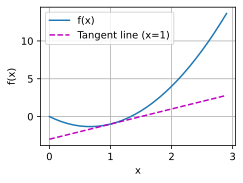

In [65]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

### 2.4.3. Partial Derivatives and Gradients

Thus far, we have been differentiating functions of just one variable. In deep learning, we also need to work with functions of *many* variables. We briefly introduce notions of the derivative that apply to such *multivariate* functions.

Let $y = f(x_1, x_2, \ldots, x_n)$ be a function with $n$ variables. The *partial derivative* of $y$ with respect to its $i^\textrm{th}$ parameter $x_i$ is

$$ \frac{\partial y}{\partial x_i} = \lim_{h \rightarrow 0} \frac{f(x_1, \ldots, x_{i-1}, x_i+h, x_{i+1}, \ldots, x_n) - f(x_1, \ldots, x_i, \ldots, x_n)}{h}. \tag{2.4.6}$$

To calculate $\frac{\partial y}{\partial x_i}$, we can treat $x_1, \ldots, x_{i-1}, x_{i+1}, \ldots, x_n$ as constants and calculate the derivative of $y$ with respect to $x_i$. The following notational conventions for partial derivatives are all common and all mean the same thing:

$$\frac{\partial y}{\partial x_i} = \frac{\partial f}{\partial x_i} = \partial_{x_i} f = \partial_i f = f_{x_i} = f_i = D_i f = D_{x_i} f. \tag{2.4.7}$$

We can concatenate partial derivatives of a multivariate function with respect to all its variables to obtain a vector that is called the *gradient* of the function. Suppose that the input of function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ is an $n$-dimensional vector $\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top$ and the output is a scalar. The gradient of the function $f$ with respect to $\mathbf{x}$ is a vector of $n$ partial derivatives:

$$\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\partial_{x_1} f(\mathbf{x}), \partial_{x_2} f(\mathbf{x}), \ldots \partial_{x_n} f(\mathbf{x})\right]^\top. \tag{2.4.8}$$

When there is no ambiguity, $\nabla_{\mathbf{x}} f(\mathbf{x})$ is typically replaced by $\nabla f(\mathbf{x})$. The following rules come in handy for differentiating multivariate functions:

* For all $\mathbf{A} \in \mathbb{R}^{m \times n}$ we have $\nabla_{\mathbf{x}} \mathbf{A} \mathbf{x} = \mathbf{A}^\top$ and $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A}  = \mathbf{A}$.

* For square matrices $\mathbf{A} \in \mathbb{R}^{n \times n}$ we have that $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A} \mathbf{x}  = (\mathbf{A} + \mathbf{A}^\top)\mathbf{x}$ and in particular $\nabla_{\mathbf{x}} \|\mathbf{x} \|^2 = \nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{x} = 2\mathbf{x}$.

Similarly, for any matrix $\mathbf{X}$, we have $\nabla_{\mathbf{X}} \|\mathbf{X} \|_\textrm{F}^2 = 2\mathbf{X}$.

### 2.4.4. Chain Rule

In deep learning, the gradients of concern are often difficult to calculate because we are working with deeply nested functions (of functions (of functions...)). Fortunately, the *chain rule* takes care of this. Returning to functions of a single variable, suppose that $y = f(g(x))$ and that the underlying functions $y=f(u)$ and $u=g(x)$ are both differentiable. The chain rule states that

$$\frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}. \tag{2.4.9}$$

Turning back to multivariate functions, suppose that $y = f(\mathbf{u})$ has variables $u_1, u_2, \ldots, u_m$, where each $u_i = g_i(\mathbf{x})$ has variables $x_1, x_2, \ldots, x_n$, i.e.,  $\mathbf{u} = g(\mathbf{x})$. Then the chain rule states that

$$\frac{\partial y}{\partial x_{i}} = \frac{\partial y}{\partial u_{1}} \frac{\partial u_{1}}{\partial x_{i}} + \frac{\partial y}{\partial u_{2}} \frac{\partial u_{2}}{\partial x_{i}} + \ldots + \frac{\partial y}{\partial u_{m}} \frac{\partial u_{m}}{\partial x_{i}} \ \textrm{ and so } \ \nabla_{\mathbf{x}} y =  \mathbf{A} \nabla_{\mathbf{u}} y, \tag{2.4.10}$$

where $\mathbf{A} \in \mathbb{R}^{n \times m}$ is a *matrix* that contains the derivative of vector $\mathbf{u}$ with respect to vector $\mathbf{x}$. Thus, evaluating the gradient requires computing a matrix--vector product. This is one of the key reasons why linear algebra is such an integral building block in building deep learning systems.

### 2.4.5. Discussion

While we have just scratched the surface of a deep topic, a number of concepts already come into focus: first, the composition rules for differentiation can be applied routinely, enabling us to compute gradients *automatically*. This task requires no creativity and thus we can focus our cognitive powers elsewhere. Second, computing the derivatives of vector-valued functions requires us to multiply matrices as we trace the dependency graph of variables from output to input. In particular, this graph is traversed in a *forward* direction when we evaluate a function and in a *backwards* direction when we compute gradients. Later chapters will formally introduce backpropagation, a computational procedure for applying the chain rule.

From the viewpoint of optimization, gradients allow us to determine how to move the parameters of a model in order to lower the loss, and each step of the optimization algorithms used throughout this book will require calculating the gradient.

### 2.4.6. Exercises

1. So far we took the rules for derivatives for granted. Using the definition and limits prove the properties for (i) $f(x) = c$, (ii) $f(x) = x^n$, (iii) $f(x) = e^x$ and (iv) $f(x) = \log x$.

1. In the same vein, prove the product, sum, and quotient rule from first principles.

1. Prove that the constant multiple rule follows as a special case of the product rule.

1. Calculate the derivative of $f(x) = x^x$.
  - $f(x) = e^{x \ln(x)}$
    - 其中用到了：$a = e^{\ln(a)} \rightarrow a^b = e^{b \ln(a)}$
  - $\frac{d}{dx} (x \ln(x)) = \ln(x) + 1$
  - $f'(x) = e^{x \ln(x)} (\ln(x) + 1) = x^x (\ln(x) + 1)$

1. What does it mean that $f'(x) = 0$ for some $x$? Give an example of a function $f$ and a location $x$ for which this might hold.

1. Plot the function $y = f(x) = x^3 - \frac{1}{x}$ and plot its tangent line at $x = 1$.

1. Find the gradient of the function $f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$.

1. What is the gradient of the function $f(\mathbf{x}) = \|\mathbf{x}\|_2$? What happens for $\mathbf{x} = \mathbf{0}$?
  - $\frac{\partial f}{\partial x_i} = \frac{x_i}{\|\mathbf{x}\|_2}$
  - $\nabla f(\mathbf{x}) = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}$
  - 对于 $\mathbf{x} = \mathbf{0}$ 的情况，由于 $|\mathbf{0}|_2 = 0$，我们通常定义 $\frac{1}{0}$ 是未定义的。然而，在实际应用中，为了保持连续性和方便处理，我们通常约定 $\nabla f(\mathbf{0}) = \mathbf{0}$。这是因为当 $\mathbf{x}$ 接近 $\mathbf{0}$ 时，函数 $f(\mathbf{x})$ 的梯度向量应该指向 $\mathbf{x}$ 的方向，但 $\mathbf{x}$ 在 $\mathbf{0}$ 处实际上是“没有方向”的，所以梯度也应该“没有方向”，即梯度向量为 $\mathbf{0}$。

1. Can you write out the chain rule for the case where $u = f(x, y, z)$ and $x = x(a, b)$, $y = y(a, b)$, and $z = z(a, b)$?

1. Given a function $f(x)$ that is invertible, compute the derivative of its inverse $f^{-1}(x)$. Here we have that $f^{-1}(f(x)) = x$ and conversely $f(f^{-1}(y)) = y$. Hint: use these properties in your derivation.

## 2.5. Automatic Differentiation

Recall from Section 2.4 that calculating derivatives is the crucial step in all the optimization algorithms that we will use to train deep networks. While the calculations are straightforward, working them out by hand can be tedious and error-prone, and these issues only grow as our models become more complex.

Fortunately all modern deep learning frameworks take this work off our plates by offering *automatic differentiation* (often shortened to *autograd*). As we pass data through each successive function, the framework builds a *computational graph* that tracks how each value depends on others. To calculate derivatives, automatic differentiation works backwards through this graph applying the chain rule. The computational algorithm for applying the chain rule in this fashion is called *backpropagation*.

While autograd libraries have become a hot concern over the past decade, they have a long history. In fact the earliest references to autograd date back over half of a century (Wengert, 1964). The core ideas behind modern backpropagation date to a PhD thesis from 1980 (Speelpenning, 1980) and were further developed in the late 1980s (Griewank, 1989). While backpropagation has become the default method for computing gradients, it is not the only option. For instance, the Julia programming language employs forward propagation (Revels et al., 2016). Before exploring methods, let's first master the autograd package.

In [ ]:
import torch

### 2.5.1. A Simple Function

Let's assume that we are interested in differentiating the function $y = 2\mathbf{x}^{\top}\mathbf{x}$ with respect to the column vector $\mathbf{x}$. To start, we assign `x` an initial value.

In [66]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

Before we calculate the gradient of $y$ with respect to $\mathbf{x}$, we need a place to store it. In general, we avoid allocating new memory every time we take a derivative because deep learning requires successively computing derivatives with respect to the same parameters a great many times, and we might risk running out of memory. Note that the gradient of a scalar-valued function with respect to a vector $\mathbf{x}$ is vector-valued with the same shape as $\mathbf{x}$.

In [67]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
print(x.grad)  # The gradient is None by default

None


We now calculate our function of `x` and assign the result to `y`.

In [68]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

We can now take the gradient of `y` with respect to `x` by calling its `backward` method. Next, we can access the gradient via `x`'s `grad` attribute.

In [69]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

We already know that the gradient of the function $y = 2\mathbf{x}^{\top}\mathbf{x}$ with respect to $\mathbf{x}$ should be $4\mathbf{x}$. We can now verify that the automatic gradient computation and the expected result are identical.

In [70]:
x.grad == 4 * x

tensor([True, True, True, True])

Now let's calculate another function of `x` and take its gradient. Note that PyTorch does not automatically reset the gradient buffer when we record a new gradient. Instead, the new gradient is added to the already-stored gradient. This behavior comes in handy when we want to optimize the sum of multiple objective functions. To reset the gradient buffer, we can call `x.grad.zero_()` as follows:

In [71]:
x.grad.zero_()  # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

### 2.5.2. Backward for Non-Scalar Variables

When `y` is a vector, the most natural representation of the derivative of  `y` with respect to a vector `x` is a matrix called the *Jacobian* that contains the partial derivatives of each component of `y` with respect to each component of `x`. Likewise, for higher-order `y` and `x`, the result of differentiation could be an even higher-order tensor.

While Jacobians do show up in some advanced machine learning techniques, more commonly we want to sum up the gradients of each component of `y` with respect to the full vector `x`, yielding a vector of the same shape as `x`. For example, we often have a vector representing the value of our loss function calculated separately for each example among a *batch* of training examples. Here, we just want to sum up the gradients computed individually for each example.

Because deep learning frameworks vary in how they interpret gradients of non-scalar tensors, PyTorch takes some steps to avoid confusion. Invoking `backward` on a non-scalar elicits an error unless we tell PyTorch how to reduce the object to a scalar. More formally, we need to provide some vector $\mathbf{v}$ such that `backward` will compute $\mathbf{v}^\top \partial_{\mathbf{x}} \mathbf{y}$ rather than $\partial_{\mathbf{x}} \mathbf{y}$. This next part may be confusing, but for reasons that will become clear later, this argument (representing $\mathbf{v}$) is named `gradient`. For a more detailed description, see Yang Zhang's [Medium post](https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29).

In [72]:
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

### 2.5.3. Detaching Computation

Sometimes, we wish to move some calculations outside of the recorded computational graph. For example, say that we use the input to create some auxiliary intermediate terms for which we do not want to compute a gradient. In this case, we need to *detach* the respective computational graph from the final result. The following toy example makes this clearer: suppose we have `z = x * y` and `y = x * x` but we want to focus on the *direct* influence of `x` on `z` rather than the influence conveyed via `y`. In this case, we can create a new variable `u` that takes the same value as `y` but whose *provenance* (how it was created) has been wiped out. Thus `u` has no ancestors in the graph and gradients do not flow through `u` to `x`. For example, taking the gradient of `z = x * u` will yield the result `u`, (not `3 * x * x` as you might have expected since `z = x * x * x`).

In [73]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

Note that while this procedure detaches `y`'s ancestors from the graph leading to `z`, the computational graph leading to `y` persists and thus we can calculate the gradient of `y` with respect to `x`.

In [74]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

### 2.5.4. Gradients and Python Control Flow

So far we reviewed cases where the path from input to output was well defined via a function such as `z = x * x * x`. Programming offers us a lot more freedom in how we compute results. For instance, we can make them depend on auxiliary variables or condition choices on intermediate results. One benefit of using automatic differentiation is that even if building the computational graph of a function required passing through a maze of Python control flow (e.g., conditionals, loops, and arbitrary function calls), we can still calculate the gradient of the resulting variable. To illustrate this, consider the following code snippet where the number of iterations of the `while` loop and the evaluation of the `if` statement both depend on the value of the input `a`.

In [75]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

Below, we call this function, passing in a random value, as input. Since the input is a random variable, we do not know what form the computational graph will take. However, whenever we execute `f(a)` on a specific input, we realize a specific computational graph and can subsequently run `backward`.

In [76]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

Even though our function `f` is, for demonstration purposes, a bit contrived, its dependence on the input is quite simple: it is a *linear* function of `a` with piecewise defined scale. As such, `f(a) / a` is a vector of constant entries and, moreover, `f(a) / a` needs to match the gradient of `f(a)` with respect to `a`.

In [77]:
a.grad == d / a

tensor(True)

Dynamic control flow is very common in deep learning. For instance, when processing text, the computational graph depends on the length of the input. In these cases, automatic differentiation becomes vital for statistical modeling since it is impossible to compute the gradient *a priori*.

### 2.5.5. Discussion

You have now gotten a taste of the power of automatic differentiation. The development of libraries for calculating derivatives both automatically and efficiently has been a massive productivity booster for deep learning practitioners, liberating them so they can focus on less menial. Moreover, autograd lets us design massive models for which pen and paper gradient computations would be prohibitively time consuming. Interestingly, while we use autograd to *optimize* models (in a statistical sense) the *optimization* of autograd libraries themselves (in a computational sense) is a rich subject of vital interest to framework designers. Here, tools from compilers and graph manipulation are leveraged to compute results in the most expedient and memory-efficient manner.

For now, try to remember these basics: (i) attach gradients to those variables with respect to which we desire derivatives; (ii) record the computation of the target value; (iii) execute the backpropagation function; and  (iv) access the resulting gradient.

### 2.5.6. Exercises

1. Why is the second derivative much more expensive to compute than the first derivative?

1. After running the function for backpropagation, immediately run it again and see what happens. Investigate.

1. In the control flow example where we calculate the derivative of `d` with respect to `a`, what would happen if we changed the variable `a` to a random vector or a matrix? At this point, the result of the calculation `f(a)` is no longer a scalar. What happens to the result? How do we analyze this?

1. Let $f(x) = \sin(x)$. Plot the graph of $f$ and of its derivative $f'$. Do not exploit the fact that $f'(x) = \cos(x)$ but rather use automatic differentiation to get the result.

1. Let $f(x) = ((\log x^2) \cdot \sin x) + x^{-1}$. Write out a dependency graph tracing results from $x$ to $f(x)$.

1. Use the chain rule to compute the derivative $\frac{df}{dx}$ of the aforementioned function, placing each term on the dependency graph that you constructed previously.

1. Given the graph and the intermediate derivative results, you have a number of options when computing the gradient. Evaluate the result once starting from $x$ to $f$ and once from $f$ tracing back to $x$. The path from $x$ to $f$ is commonly known as *forward differentiation*, whereas the path from $f$ to $x$ is known as backward differentiation.

1. When might you want to use forward, and when backward, differentiation? Hint: consider the amount of intermediate data needed, the ability to parallelize steps, and the size of matrices and vectors involved.

## 2.6. Probability and Statistics

One way or another, machine learning is all about uncertainty. In supervised learning, we want to predict something unknown (the *target*) given something known (the *features*). Depending on our objective, we might attempt to predict the most likely value of the target. Or we might predict the value with the smallest expected distance from the target. And sometimes we wish not only to predict a specific value but to *quantify our uncertainty*. For example, given some features describing a patient, we might want to know *how likely* they are to suffer a heart attack in the next year. In unsupervised learning, we often care about uncertainty. To determine whether a set of measurements are anomalous, it helps to know how likely one is to observe values in a population of interest. Furthermore, in reinforcement learning, we wish to develop agents that act intelligently in various environments. This requires reasoning about how an environment might be expected to change and what rewards one might expect to encounter in response to each of the available actions.

*Probability* is the mathematical field concerned with reasoning under uncertainty. Given a probabilistic model of some process, we can reason about the likelihood of various events. The use of probabilities to describe the frequencies of repeatable events (like coin tosses) is fairly uncontroversial. In fact, *frequentist* scholars adhere to an interpretation of probability that applies *only* to such repeatable events. By contrast *Bayesian* scholars use the language of probability more broadly to formalize reasoning under uncertainty. Bayesian probability is characterized by two unique features: (i) assigning degrees of belief to non-repeatable events, e.g., what is the *probability* that a dam will collapse?; and (ii) subjectivity. While Bayesian probability provides unambiguous rules for how one should update their beliefs in light of new evidence, it allows for different individuals to start off with different *prior* beliefs. *Statistics* helps us to reason backwards, starting off with collection and organization of data and backing out to what inferences we might draw about the process that generated the data. Whenever we analyze a dataset, hunting for patterns that we hope might characterize a broader population, we are employing statistical thinking. Many courses, majors, theses, careers, departments, companies, and institutions have been devoted to the study of probability and statistics. While this section only scratches the surface, we will provide the foundation that you need to begin building models.

In [78]:
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

### 2.6.1. A Simple Example: Tossing Coins

Imagine that we plan to toss a coin and want to quantify how likely we are to see heads (vs. tails). If the coin is *fair*, then both outcomes (heads and tails), are equally likely. Moreover if we plan to toss the coin $n$ times then the fraction of heads that we *expect* to see should exactly match the *expected* fraction of tails. One intuitive way to see this is by symmetry: for every possible outcome with $n_\textrm{h}$ heads and $n_\textrm{t} = (n - n_\textrm{h})$ tails, there is an equally likely outcome with $n_\textrm{t}$ heads and $n_\textrm{h}$ tails. Note that this is only possible if on average we expect to see $1/2$ of tosses come up heads and $1/2$ come up tails. Of course, if you conduct this experiment many times with $n=1000000$ tosses each, you might never see a trial where $n_\textrm{h} = n_\textrm{t}$ exactly.

Formally, the quantity $1/2$ is called a ***probability*** and here it captures the certainty with which any given toss will come up heads. Probabilities assign scores between $0$ and $1$ to outcomes of interest, called ***events***. Here the event of interest is $\textrm{heads}$ and we denote the corresponding probability $P(\textrm{heads})$. A probability of $1$ indicates absolute certainty (imagine a trick coin where both sides were heads) and a probability of $0$ indicates impossibility (e.g., if both sides were tails). The frequencies $n_\textrm{h}/n$ and $n_\textrm{t}/n$ are not probabilities but rather ***statistics***. Probabilities are *theoretical* quantities that underly the data generating process. Here, the probability $1/2$ is a property of the coin itself. By contrast, statistics are *empirical* quantities that are computed as functions of the observed data. Our interests in probabilistic and statistical quantities are inextricably intertwined. We often design special statistics called ***estimators*** that, given a dataset, produce ***estimates*** of model parameters such as probabilities. Moreover, when those estimators satisfy a nice property called *consistency*, our estimates will converge to the corresponding probability. In turn, these inferred probabilities tell about the likely statistical properties of data from the same population that we might encounter in the future.

Suppose that we stumbled upon a real coin for which we did not know the true $P(\textrm{heads})$. To investigate this quantity with statistical methods, we need to (i) collect some data; and (ii) design an estimator. Data acquisition here is easy; we can toss the coin many times and record all the outcomes. Formally, drawing realizations from some underlying random process is called ***sampling***. As you might have guessed, one natural estimator is the ratio of the number of observed *heads* to the total number of tosses.

Now, suppose that the coin was in fact fair, i.e., $P(\textrm{heads}) = 0.5$. To simulate tosses of a fair coin, we can invoke any random number generator. There are some easy ways to draw samples of an event with probability $0.5$. For example Python's `random.random` yields numbers in the interval $[0,1]$ where the probability of lying in any sub-interval $[a, b] \subset [0,1]$ is equal to $b-a$. Thus we can get out `0` and `1` with probability `0.5` each by testing whether the returned float number is greater than `0.5`:

In [79]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [51, 49]


More generally, we can simulate multiple draws from any variable with a finite number of possible outcomes (like the toss of a coin or roll of a die) by calling the multinomial function, setting the first argument to the number of draws and the second as a list of probabilities associated with each of the possible outcomes. To simulate 100 tosses of a fair coin, we assign probability vector `[0.5, 0.5]`, interpreting index 0 as heads and index 1 as tails. The function returns a vector with length equal to the number of possible outcomes (here, 2), where the first component tells us the number of occurrences of heads and the second component tells us the number of occurrences of tails.

In [80]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([46., 54.])

Each time you run this sampling process, you will receive a new random value that may differ from the previous outcome. Dividing by the number of tosses gives us the ***frequency*** of each outcome in our data. Note that these frequencies, just like the probabilities that they are intended to estimate, sum to $1$.

In [81]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.5500, 0.4500])

Here, even though our simulated coin is fair (we ourselves set the probabilities `[0.5, 0.5]`), the counts of heads and tails may not be identical. That is because we only drew a relatively small number of samples. If we did not implement the simulation ourselves, and only saw the outcome, how would we know if the coin were slightly unfair or if the possible deviation from $1/2$ was just an artifact of the small sample size? Let's see what happens when we simulate 10,000 tosses.

In [82]:
counts = Multinomial(10000, fair_probs).sample()
counts / 10000

tensor([0.4961, 0.5039])

In general, for averages of repeated events (like coin tosses), as the number of repetitions grows, our estimates are guaranteed to converge to the true underlying probabilities. The mathematical formulation of this phenomenon is called the ***law of large numbers*** and the ***central limit theorem*** tells us that in many situations, as the sample size $n$ grows, these errors should go down at a rate of $(1/\sqrt{n})$. Let's get some more intuition by studying how our estimate evolves as we grow the number of tosses from 1 to 10,000.

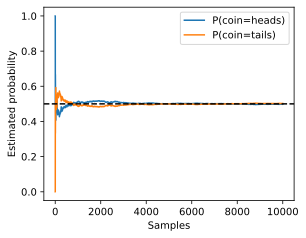

In [83]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

---
牧之：注意 `counts = Multinomial(10000, fair_probs).sample()` 和 `counts = Multinomial(1, fair_probs).sample((10000,))` 的区别。

In [84]:
counts_ = Multinomial(10000, fair_probs).sample()
print(counts_)
print(counts_.shape)

counts_ = Multinomial(1, fair_probs).sample((10000,))
print(counts_)
print(counts_.shape)
print(counts_.sum(dim=0))

tensor([4976., 5024.])
torch.Size([2])
tensor([[1., 0.],
        [0., 1.],
        [1., 0.],
        ...,
        [1., 0.],
        [1., 0.],
        [0., 1.]])
torch.Size([10000, 2])
tensor([5053., 4947.])


Each solid curve corresponds to one of the two values of the coin and gives our estimated probability that the coin turns up that value after each group of experiments. The dashed black line gives the true underlying probability. As we get more data by conducting more experiments, the curves converge towards the true probability. You might already begin to see the shape of some of the more advanced questions that preoccupy statisticians: How quickly does this convergence happen? If we had already tested many coins manufactured at the same plant, how might we incorporate this information?

### 2.6.2. A More Formal Treatment

We have already gotten pretty far: posing a probabilistic model, generating synthetic data, running a statistical estimator, empirically assessing convergence, and reporting error metrics (checking the deviation). However, to go much further, we will need to be more precise.

When dealing with randomness, we denote the set of possible outcomes $\mathcal{S}$ and call it the *sample space* or *outcome space*. Here, each element is a distinct possible *outcome*. In the case of rolling a single coin, $\mathcal{S} = \{\textrm{heads}, \textrm{tails}\}$. For a single die, $\mathcal{S} = \{1, 2, 3, 4, 5, 6\}$. When flipping two coins, possible outcomes are $\{(\textrm{heads}, \textrm{heads}), (\textrm{heads}, \textrm{tails}), (\textrm{tails}, \textrm{heads}),  (\textrm{tails}, \textrm{tails})\}$. *Events* are subsets of the sample space. For instance, the event "the first coin toss comes up heads" corresponds to the set $\{(\textrm{heads}, \textrm{heads}), (\textrm{heads}, \textrm{tails})\}$. Whenever the outcome $z$ of a random experiment satisfies $z \in \mathcal{A}$, then event $\mathcal{A}$ has occurred. For a single roll of a die, we could define the events "seeing a $5$" ($\mathcal{A} = \{5\}$) and "seeing an odd number"  ($\mathcal{B} = \{1, 3, 5\}$). In this case, if the die came up $5$, we would say that both $\mathcal{A}$ and $\mathcal{B}$ occurred. On the other hand, if $z = 3$, then $\mathcal{A}$ did not occur but $\mathcal{B}$ did.

A *probability* function maps events onto real values ${P: \mathcal{A} \subseteq \mathcal{S} \rightarrow [0,1]}$. The probability, denoted $P(\mathcal{A})$, of an event $\mathcal{A}$ in the given sample space $\mathcal{S}$, has the following properties:

* The probability of any event $\mathcal{A}$ is a nonnegative real number, i.e., $P(\mathcal{A}) \geq 0$;

* The probability of the entire sample space is $1$, i.e., $P(\mathcal{S}) = 1$;

* For any countable sequence of events $\mathcal{A}_1, \mathcal{A}_2, \ldots$ that are *mutually exclusive* (i.e., $\mathcal{A}_i \cap \mathcal{A}_j = \emptyset$ for all $i \neq j$), the probability that any of them happens is equal to the sum of their individual probabilities, i.e., $P(\bigcup_{i=1}^{\infty} \mathcal{A}_i) = \sum_{i=1}^{\infty} P(\mathcal{A}_i)$.

These axioms of probability theory, proposed by Kolmogorov (1933), can be applied to rapidly derive a number of important consequences. For instance, it follows immediately that the probability of any event $\mathcal{A}$ *or* its complement $\mathcal{A}'$ occurring is 1 (because $\mathcal{A} \cup \mathcal{A}' = \mathcal{S}$). We can also prove that $P(\emptyset) = 0$ because $1 = P(\mathcal{S} \cup \mathcal{S}') = P(\mathcal{S} \cup \emptyset) = P(\mathcal{S}) + P(\emptyset) = 1 + P(\emptyset)$. Consequently, the probability of any event $\mathcal{A}$ *and* its complement $\mathcal{A}'$ occurring simultaneously is $P(\mathcal{A} \cap \mathcal{A}') = 0$. Informally, this tells us that impossible events have zero probability of occurring.

### 2.6.3. Random Variables

When we spoke about events like the roll of a die coming up odds or the first coin toss coming up heads, we were invoking the idea of a *random variable*. Formally, random variables are mappings from an underlying sample space to a set of (possibly many) values. You might wonder how a random variable is different from the sample space, since both are collections of outcomes. Importantly, random variables can be much coarser than the raw sample space. We can define a binary random variable like "greater than 0.5" even when the underlying sample space is infinite, e.g., points on the line segment between $0$ and $1$. Additionally, multiple random variables can share the same underlying sample space. For example "whether my home alarm goes off" and "whether my house was burgled" are both binary random variables that share an underlying sample space. Consequently, knowing the value taken by one random variable can tell us something about the likely value of another random variable. Knowing that the alarm went off, we might suspect that the house was likely burgled.

Every value taken by a random variable corresponds to a subset of the underlying sample space. Thus the occurrence where the random variable $X$ takes value $v$, denoted by $X=v$, is an *event* and $P(X=v)$ denotes its probability. Sometimes this notation can get clunky, and we can abuse notation when the context is clear. For example, we might use $P(X)$ to refer broadly to the *distribution* of $X$, i.e., the function that tells us the probability that $X$ takes any given value. Other times we write expressions like $P(X,Y) = P(X) P(Y)$, as a shorthand to express a statement that is true for all of the values that the random variables $X$ and $Y$ can take, i.e., for all $i,j$ it holds that $P(X=i \textrm{ and } Y=j) = P(X=i)P(Y=j)$. Other times, we abuse notation by writing $P(v)$ when the random variable is clear from the context. Since an event in probability theory is a set of outcomes from the sample space, we can specify a range of values for a random variable to take. For example, $P(1 \leq X \leq 3)$ denotes the probability of the event $\{1 \leq X \leq 3\}$.

Note that there is a subtle difference between *discrete* random variables, like flips of a coin or tosses of a die, and *continuous* ones, like the weight and the height of a person sampled at random from the population. In this case we seldom really care about someone's exact height. Moreover, if we took precise enough measurements, we would find that no two people on the planet have the exact same height. In fact, with fine enough measurements, you would never have the same height when you wake up and when you go to sleep. There is little point in asking about the exact probability that someone is 1.801392782910287192 meters tall. Instead, we typically care more about being able to say whether someone's height falls into a given interval, say between 1.79 and 1.81 meters. In these cases we work with probability *densities*. The height of exactly 1.80 meters has no probability, but nonzero density. To work out the probability assigned to an interval, we must take an *integral* of the density over that interval.

### 2.6.4. Multiple Random Variables

You might have noticed that we could not even make it through the previous section without making statements involving interactions among multiple random variables (recall $P(X,Y) = P(X) P(Y)$). Most of machine learning is concerned with such relationships. Here, the sample space would be the population of interest, say customers who transact with a business, photographs on the Internet, or proteins known to biologists. Each random variable would represent the (unknown) value of a different attribute. Whenever we sample an individual from the population, we observe a realization of each of the random variables. Because the values taken by random variables correspond to subsets of the sample space that could be overlapping, partially overlapping, or entirely disjoint, knowing the value taken by one random variable can cause us to update our beliefs about which values of another random variable are likely. If a patient walks into a hospital and we observe that they are having trouble breathing and have lost their sense of smell, then we believe that they are more likely to have COVID-19 than we might if they had no trouble breathing and a perfectly ordinary sense of smell.

When working with multiple random variables, we can construct events corresponding to every combination of values that the variables can jointly take. The probability function that assigns probabilities to each of these combinations (e.g. $A=a$ and $B=b$) is called the *joint probability* function and simply returns the probability assigned to the intersection of the corresponding subsets of the sample space. The *joint probability* assigned to the event where random variables $A$ and $B$ take values $a$ and $b$, respectively, is denoted $P(A = a, B = b)$, where the comma indicates "and". Note that for any values $a$ and $b$, it follows that

$$P(A=a, B=b) \leq P(A=a) \textrm{ and } P(A=a, B=b) \leq P(B = b), \tag{2.6.1}$$

since for $A=a$ and $B=b$ to happen, $A=a$ has to happen *and* $B=b$ also has to happen. Interestingly, the joint probability tells us all that we can know about these random variables in a probabilistic sense, and can be used to derive many other useful quantities, including recovering the individual distributions $P(A)$ and $P(B)$. To recover $P(A=a)$ we simply sum up $P(A=a, B=v)$ over all values $v$ that the random variable $B$ can take: $P(A=a) = \sum_v P(A=a, B=v)$.

The ratio $\frac{P(A=a, B=b)}{P(A=a)} \leq 1$ turns out to be extremely important. It is called the *conditional probability*, and is denoted via the "$\mid$" symbol:

$$P(B=b \mid A=a) = P(A=a,B=b)/P(A=a). \tag{2.6.2}$$

It tells us the new probability associated with the event $B=b$, once we condition on the fact $A=a$ took place. We can think of this conditional probability as restricting attention only to the subset of the sample space associated with $A=a$ and then renormalizing so that all probabilities sum to 1. Conditional probabilities are in fact just ordinary probabilities and thus respect all of the axioms, as long as we condition all terms on the same event and thus restrict attention to the same sample space. For instance, for disjoint events $\mathcal{B}$ and $\mathcal{B}'$, we have that $P(\mathcal{B} \cup \mathcal{B}' \mid A = a) = P(\mathcal{B} \mid A = a) + P(\mathcal{B}' \mid A = a)$.

Using the definition of conditional probabilities, we can derive the famous result called *Bayes' theorem*. By construction, we have that $P(A, B) = P(B\mid A) P(A)$ and $P(A, B) = P(A\mid B) P(B)$. Combining both equations yields $P(B\mid A) P(A) = P(A\mid B) P(B)$ and hence

$$P(A \mid B) = \frac{P(B\mid A) P(A)}{P(B)}. \tag{2.6.3}$$

This simple equation has profound implications because it allows us to reverse the order of conditioning. If we know how to estimate $P(B\mid A)$, $P(A)$, and $P(B)$, then we can estimate $P(A\mid B)$. We often find it easier to estimate one term directly but not the other and Bayes' theorem can come to the rescue here. For instance, if we know the prevalence of symptoms for a given disease, and the overall prevalences of the disease and symptoms, respectively, we can determine how likely someone is to have the disease based on their symptoms. In some cases we might not have direct access to $P(B)$, such as the prevalence of symptoms. In this case a simplified version of Bayes' theorem comes in handy:

$$P(A \mid B) \propto P(B \mid A) P(A). \tag{2.6.4}$$

Since we know that $P(A \mid B)$ must be normalized to $1$, i.e., $\sum_a P(A=a \mid B) = 1$, we can use it to compute

$$P(A \mid B) = \frac{P(B \mid A) P(A)}{\sum_a P(B \mid A=a) P(A = a)}. \tag{2.6.5}$$

In Bayesian statistics, we think of an observer as possessing some (subjective) prior beliefs about the plausibility of the available hypotheses encoded in the *prior* $P(H)$, and a *likelihood function* that says how likely one is to observe any value of the collected evidence for each of the hypotheses in the class $P(E \mid H)$. Bayes' theorem is then interpreted as telling us how to update the initial *prior* $P(H)$ in light of the available evidence $E$ to produce *posterior* beliefs $P(H \mid E) = \frac{P(E \mid H) P(H)}{P(E)}$. Informally, this can be stated as "***posterior equals prior times likelihood, divided by the evidence***". Now, because the evidence $P(E)$ is the same for all hypotheses, we can get away with simply normalizing over the hypotheses.

Note that $\sum_a P(A=a \mid B) = 1$ also allows us to *marginalize* over random variables. That is, we can drop variables from a joint distribution such as $P(A, B)$. After all, we have that

$$\sum_a P(B \mid A=a) P(A=a) = \sum_a P(B, A=a) = P(B). \tag{2.6.6}$$

Independence is another fundamentally important concept that forms the backbone of many important ideas in statistics. In short, two variables are *independent* if conditioning on the value of $A$ does not cause any change to the probability distribution associated with $B$ and vice versa. More formally, independence, denoted $A \perp B$, requires that $P(A \mid B) = P(A)$ and, consequently, that $P(A,B) = P(A \mid B) P(B) = P(A) P(B)$. Independence is often an appropriate assumption. For example, if the random variable $A$ represents the outcome from tossing one fair coin and the random variable $B$ represents the outcome from tossing another, then knowing whether $A$ came up heads should not influence the probability of $B$ coming up heads.

Independence is especially useful when it holds among the successive draws of our data from some underlying distribution (allowing us to make strong statistical conclusions) or when it holds among various variables in our data, allowing us to work with simpler models that encode this independence structure. On the other hand, estimating the dependencies among random variables is often the very aim of learning. We care to estimate the probability of disease given symptoms specifically because we believe that diseases and symptoms are *not* independent.

Note that because conditional probabilities are proper probabilities, the concepts of independence and dependence also apply to them. Two random variables $A$ and $B$ are *conditionally independent* given a third variable $C$ if and only if $P(A, B \mid C) = P(A \mid C)P(B \mid C)$. Interestingly, two variables can be independent in general but become dependent when conditioning on a third. This often occurs when the two random variables $A$ and $B$ correspond to causes of some third variable $C$. For example, broken bones and lung cancer might be independent in the general population but if we condition on being in the hospital then we might find that broken bones are negatively correlated with lung cancer. That is because the broken bone *explains away* why some person is in the hospital and thus lowers the probability that they are hospitalized because of having lung cancer.

And conversely, two dependent random variables can become independent upon conditioning on a third. This often happens when two otherwise unrelated events have a common cause. Shoe size and reading level are highly correlated among elementary school students, but this correlation disappears if we condition on age.

---
牧之：
- 随机变量可以比事件更高效地表达事物。
- 联合概率可用于估算单独概率。
- 条件概率是压缩了采样空间。
- 贝叶斯公式可以帮助我们反转条件 —— 在现实生活中，估算某个随机变量比另一个随机变量要简单得多。

### 2.6.5. An Example

Let's put our skills to the test. Assume that a doctor administers an HIV test to a patient. This test is fairly accurate and fails only with 1% probability if the patient is healthy but reported as diseased, i.e., healthy patients test positive in 1% of cases. Moreover, it never fails to detect HIV if the patient actually has it. We use $D_1 \in \{0, 1\}$ to indicate the diagnosis ($0$ if negative and $1$ if positive) and $H \in \{0, 1\}$ to denote the HIV status.

| Conditional probability | $$H=1$$ | $$H=0$$ |
|:------------------------|--------:|--------:|
| $P(D_1 = 1 \mid H)$     |       1 |    0.01 |
| $P(D_1 = 0 \mid H)$     |       0 |    0.99 |

Let's compute the probability of the patient having HIV if the test comes back positive, i.e., $P(H = 1 \mid D_1 = 1)$. Intuitively this is going to depend on how common the disease is, since it affects the number of false alarms. Assume that the population is fairly free of the disease, e.g., $P(H=1) = 0.0015$. To apply Bayes' theorem, we need to apply marginalization to determine

$$\begin{aligned}
P(D_1 = 1)
=& P(D_1=1, H=0) + P(D_1=1, H=1)  \\
=& P(D_1=1 \mid H=0) P(H=0) + P(D_1=1 \mid H=1) P(H=1) \\
=& 0.011485.
\end{aligned} \tag{2.6.7}
$$

This leads us to

$$P(H = 1 \mid D_1 = 1) = \frac{P(D_1=1 \mid H=1) P(H=1)}{P(D_1=1)} = 0.1306. \tag{2.6.8}$$

In other words, there is only a 13.06% chance that the patient actually has HIV, despite the test being pretty accurate. As we can see, **probability can be counterintuitive**. What should a patient do upon receiving such terrifying news? Likely, the patient would ask the physician to administer another test to get clarity. The second test has different characteristics and it is not as good as the first one.

| Conditional probability | $$H=1$$ | $$H=0$$ |
|:------------------------|--------:|--------:|
| $P(D_2 = 1 \mid H)$     |  0.98   |  0.03   |
| $P(D_2 = 0 \mid H)$     |  0.02   |  0.97   |

Unfortunately, the second test comes back positive, too. Let's calculate the requisite probabilities to invoke Bayes' theorem by assuming conditional independence:

$$\begin{aligned}
P(D_1 = 1, D_2 = 1 \mid H = 0)
& = P(D_1 = 1 \mid H = 0) P(D_2 = 1 \mid H = 0)
=& 0.0003, \\
P(D_1 = 1, D_2 = 1 \mid H = 1)
& = P(D_1 = 1 \mid H = 1) P(D_2 = 1 \mid H = 1)
=& 0.98.
\end{aligned} \tag{2.6.9}
$$

Now we can apply marginalization to obtain the probability that both tests come back positive:

$$\begin{aligned}
&P(D_1 = 1, D_2 = 1)\\
&= P(D_1 = 1, D_2 = 1, H = 0) + P(D_1 = 1, D_2 = 1, H = 1)  \\
&= P(D_1 = 1, D_2 = 1 \mid H = 0)P(H=0) + P(D_1 = 1, D_2 = 1 \mid H = 1)P(H=1)\\
&= 0.00176955.
\end{aligned} \tag{2.6.10}
$$

Finally, the probability of the patient having HIV given that both tests are positive is

$$P(H = 1 \mid D_1 = 1, D_2 = 1)
= \frac{P(D_1 = 1, D_2 = 1 \mid H=1) P(H=1)}{P(D_1 = 1, D_2 = 1)}
= 0.8307. \tag{2.6.11}$$

That is, the second test allowed us to gain much higher confidence that not all is well. Despite the second test being considerably less accurate than the first one, it still significantly improved our estimate. The assumption of both tests being conditionally independent of each other was crucial for our ability to generate a more accurate estimate. Take the extreme case where we run the same test twice. In this situation we would expect the same outcome both times, hence no additional insight is gained from running the same test again. The astute reader might have noticed that the diagnosis behaved like a classifier hiding in plain sight where our ability to decide whether a patient is healthy increases as we obtain more features (test outcomes).

### 2.6.6. Expectations

Often, making decisions requires not just looking at the probabilities assigned to individual events but composing them together into useful aggregates that can provide us with guidance. For example, when random variables take continuous scalar values, we often care about knowing what value to expect *on average*. This quantity is formally called an *expectation*. If we are making investments, the first quantity of interest might be the return we can expect, averaging over all the possible outcomes (and weighting by the appropriate probabilities). For instance, say that with 50% probability, an investment might fail altogether, with 40% probability it might provide a 2$\times$ return, and with 10% probability it might provide a 10$\times$ return. To calculate the expected return, we sum over all returns, multiplying each by the probability that they will occur. This yields the expectation $0.5 \cdot 0 + 0.4 \cdot 2 + 0.1 \cdot 10 = 1.8$. Hence the expected return is 1.8$\times$.

In general, the *expectation* (or average) of the random variable $X$ is defined as

$$E[X] = E_{x \sim P}[x] = \sum_{x} x P(X = x). \tag{2.6.12}$$

Likewise, for densities we obtain $E[X] = \int x \;dp(x)$. Sometimes we are interested in the expected value of some function of $x$. We can calculate these expectations as

$$E_{x \sim P}[f(x)] = \sum_x f(x) P(x) \textrm{ and } E_{x \sim P}[f(x)] = \int f(x) p(x) \;dx \tag{2.6.13}$$

for discrete probabilities and densities, respectively. Returning to the investment example from above, $f$ might be the *utility* (happiness) associated with the return. Behavior economists have long noted that people associate greater disutility with losing money than the utility gained from earning one dollar relative to their baseline. Moreover, the value of money tends to be sub-linear. Possessing 100k dollars versus zero dollars can make the difference between paying the rent, eating well, and enjoying quality healthcare versus suffering through homelessness. On the other hand, the gains due to possessing 200k versus 100k are less dramatic. Reasoning like this motivates the cliché that "the utility of money is logarithmic".

If  the utility associated with a total loss were $-1$, and the utilities associated with returns of $1$, $2$, and $10$ were $1$, $2$ and $4$, respectively, then the expected happiness of investing would be $0.5 \cdot (-1) + 0.4 \cdot 2 + 0.1 \cdot 4 = 0.7$ (an expected loss of utility of 30%). If indeed this were your utility function, you might be best off keeping the money in the bank.

For financial decisions, we might also want to measure how *risky* an investment is. Here, we care not just about the expected value but how much the actual values tend to *vary* relative to this value. Note that we cannot just take the expectation of the difference between the actual and expected values. This is because the expectation of a difference is the difference of the expectations, i.e., $E[X - E[X]] = E[X] - E[E[X]] = 0$. However, we can look at the expectation of any non-negative function of this difference. The *variance* of a random variable is calculated by looking at the expected value of the *squared* differences:

$$\textrm{Var}[X] = E\left[(X - E[X])^2\right] = E[X^2] - E[X]^2. \tag{2.6.14}$$

Here the equality follows by expanding $(X - E[X])^2 = X^2 - 2 X E[X] + E[X]^2$ and taking expectations for each term. The square root of the variance is another useful quantity called the *standard deviation*. While this and the variance convey the same information (either can be calculated from the other), the standard deviation has the nice property that it is expressed in the same units as the original quantity represented by the random variable.

Lastly, the variance of a function of a random variable is defined analogously as

$$\textrm{Var}_{x \sim P}[f(x)] = E_{x \sim P}[f^2(x)] - E_{x \sim P}[f(x)]^2. \tag{2.6.15}$$

Returning to our investment example, we can now compute the variance of the investment. It is given by $0.5 \cdot 0 + 0.4 \cdot 2^2 + 0.1 \cdot 10^2 - 1.8^2 = 8.36$. For all intents and purposes this is a risky investment. Note that by mathematical convention mean and variance are often referenced as $\mu$ and $\sigma^2$. This is particularly the case whenever we use it to parametrize a Gaussian distribution.

In the same way as we introduced expectations and variance for *scalar* random variables, we can do so for vector-valued ones. Expectations are easy, since we can apply them elementwise. For instance, $\boldsymbol{\mu} \stackrel{\textrm{def}}{=} E_{\mathbf{x} \sim P}[\mathbf{x}]$ has coordinates $\mu_i = E_{\mathbf{x} \sim P}[x_i]$. *Covariances* are more complicated. We define them by taking expectations of the *outer product* of the difference between random variables and their mean:

$$\boldsymbol{\Sigma} \stackrel{\textrm{def}}{=} \textrm{Cov}_{\mathbf{x} \sim P}[\mathbf{x}] = E_{\mathbf{x} \sim P}\left[(\mathbf{x} - \boldsymbol{\mu}) (\mathbf{x} - \boldsymbol{\mu})^\top\right]. \tag{2.6.16}$$

This matrix $\boldsymbol{\Sigma}$ is referred to as the covariance matrix. An easy way to see its effect is to consider some vector $\mathbf{v}$ of the same size as $\mathbf{x}$. It follows that

$$\mathbf{v}^\top \boldsymbol{\Sigma} \mathbf{v} = E_{\mathbf{x} \sim P}\left[\mathbf{v}^\top(\mathbf{x} - \boldsymbol{\mu}) (\mathbf{x} - \boldsymbol{\mu})^\top \mathbf{v}\right] = \textrm{Var}_{x \sim P}[\mathbf{v}^\top \mathbf{x}]. \tag{2.6.17}$$

As such, $\boldsymbol{\Sigma}$ allows us to compute the variance for any linear function of $\mathbf{x}$ by a simple matrix multiplication. The off-diagonal elements tell us how correlated the coordinates are: a value of 0 means no correlation, where a larger positive value means that they are more strongly correlated.

---

牧之：对于标量随机变量，方差可以通过计算随机变量与其均值的差的平方来得到。对于向量值随机变量，我们希望得到类似的性质。因此，我们引入了协方差矩阵 $\boldsymbol{\Sigma}$。当我们考虑某个与 $\mathbf{x}$ 同样大小的向量 $\mathbf{v}$ 时，$\mathbf{v}^\top \boldsymbol{\Sigma} \mathbf{v}$ 可以被看作是 $\mathbf{v}^\top \mathbf{x}$ 的方差。这意味着协方差矩阵 $\boldsymbol{\Sigma}$ 允许我们通过简单的矩阵乘法来计算 $\mathbf{x}$ 的任何线性函数的方差。这是因为方差本质上是对变量与其均值之间差的平方的期望，而协方差矩阵直接捕捉了这种关系。

### 2.6.7. Discussion

In machine learning, there are many things to be uncertain about! We can be uncertain about the value of a label given an input. We can be uncertain about the estimated value of a parameter. We can even be uncertain about whether data arriving at deployment is even from the same distribution as the training data.

By *aleatoric uncertainty*, we mean uncertainty that is intrinsic to the problem, and due to genuine randomness unaccounted for by the observed variables. By *epistemic uncertainty*, we mean uncertainty over a model's parameters, the sort of uncertainty that we can hope to reduce by collecting more data. We might have epistemic uncertainty concerning the probability that a coin turns up heads, but even once we know this probability, we are left with aleatoric uncertainty about the outcome of any future toss. No matter how long we watch someone tossing a fair coin, we will never be more or less than 50% certain that the next toss will come up heads. These terms come from mechanical modeling, (see e.g., Der Kiureghian and Ditlevsen (2009) for a review on this aspect of [uncertainty quantification](https://en.wikipedia.org/wiki/Uncertainty_quantification)). It is worth noting, however, that these terms constitute a slight abuse of language. The term *epistemic* refers to anything concerning *knowledge* and thus, in the philosophical sense, all uncertainty is epistemic.

We saw that sampling data from some unknown probability distribution can provide us with information that can be used to estimate the parameters of the data generating distribution. That said, the rate at which this is possible can be quite slow. In our coin tossing example (and many others) we can do no better than to design estimators that converge at a rate of $1/\sqrt{n}$, where $n$ is the sample size (e.g., the number of tosses). This means that by going from 10 to 1000 observations (usually a very achievable task) we see a tenfold reduction of uncertainty, whereas the next 1000 observations help comparatively little, offering only a 1.41 times reduction. This is a persistent feature of machine learning: *while there are often easy gains, it takes a very large amount of data, and often with it an enormous amount of computation, to make further gains*. For an empirical review of this fact for large scale language models see Revels et al. (2016).

We also sharpened our language and tools for statistical modeling. In the process of that we learned about conditional probabilities and about one of the most important equations in statistics---Bayes' theorem. It is an effective tool for decoupling information conveyed by data through a likelihood term $P(B \mid A)$ that addresses how well observations $B$ match a choice of parameters $A$, and a prior probability $P(A)$ which governs how plausible a particular choice of $A$ was in the first place. In particular, we saw how this rule can be applied to assign probabilities to diagnoses, based on the efficacy of the test *and* the prevalence of the disease itself (i.e., our prior).

Lastly, we introduced a first set of nontrivial questions about the effect of a specific probability distribution, namely expectations and variances. While there are many more than just linear and quadratic expectations for a probability distribution, these two already provide a good deal of knowledge about the possible behavior of the distribution. For instance, [Chebyshev's inequality](https://en.wikipedia.org/wiki/Chebyshev%27s_inequality) states that $P(|X - \mu| \geq k \sigma) \leq 1/k^2$, where $\mu$ is the expectation, $\sigma^2$ is the variance of the distribution, and $k > 1$ is a confidence parameter of our choosing. It tells us that draws from a distribution lie with at least 50% probability within a $[-\sqrt{2} \sigma, \sqrt{2} \sigma]$ interval centered on the expectation.

### 2.6.8. Exercises

1. Give an example where observing more data can reduce the amount of uncertainty about the outcome to an arbitrarily low level.

1. Give an example where observing more data will only reduce the amount of uncertainty up to a point and then no further. Explain why this is the case and where you expect this point to occur.

1. We empirically demonstrated convergence to the mean for the toss of a coin. Calculate the variance of the estimate of the probability that we see a head after drawing $n$ samples.
    - How does the variance scale with the number of observations?
    - Use Chebyshev's inequality to bound the deviation from the expectation.
    - How does it relate to the central limit theorem?

1. Assume that we draw $m$ samples $x_i$ from a probability distribution with zero mean and unit variance. Compute the averages $z_m \stackrel{\textrm{def}}{=} m^{-1} \sum_{i=1}^m x_i$. Can we apply Chebyshev's inequality for every $z_m$ independently? Why not?

1. Given two events with probability $P(\mathcal{A})$ and $P(\mathcal{B})$, compute upper and lower bounds on $P(\mathcal{A} \cup \mathcal{B})$ and $P(\mathcal{A} \cap \mathcal{B})$. Hint: graph the situation using a [Venn diagram](https://en.wikipedia.org/wiki/Venn_diagram).

1. Assume that we have a sequence of random variables, say $A$, $B$, and $C$, where $B$ only depends on $A$, and $C$ only depends on $B$, can you simplify the joint probability $P(A, B, C)$? Hint: this is a [Markov chain](https://en.wikipedia.org/wiki/Markov_chain).

1. In Section 2.6.5, assume that the outcomes of the two tests are not independent. In particular assume that either test on its own has a false positive rate of 10% and a false negative rate of 1%. That is, assume that $P(D =1 \mid H=0) = 0.1$ and that $P(D = 0 \mid H=1) = 0.01$. Moreover, assume that for $H = 1$ (infected) the test outcomes are conditionally independent, i.e., that $P(D_1, D_2 \mid H=1) = P(D_1 \mid H=1) P(D_2 \mid H=1)$ but that for healthy patients the outcomes are coupled via $P(D_1 = D_2 = 1 \mid H=0) = 0.02$.
    - Work out the joint probability table for $D_1$ and $D_2$, given $H=0$ based on the information you have so far.
    - Derive the probability that the patient is diseased ($H=1$) after one test returns positive. You can assume the same baseline probability $P(H=1) = 0.0015$ as before.
    - Derive the probability that the patient is diseased ($H=1$) after both tests return positive.

1. Assume that you are an asset manager for an investment bank and you have a choice of stocks $s_i$ to invest in. Your portfolio needs to add up to $1$ with weights $\alpha_i$ for each stock. The stocks have an average return $\boldsymbol{\mu} = E_{\mathbf{s} \sim P}[\mathbf{s}]$ and covariance $\boldsymbol{\Sigma} = \textrm{Cov}_{\mathbf{s} \sim P}[\mathbf{s}]$.
    - Compute the expected return for a given portfolio $\boldsymbol{\alpha}$.
    - If you wanted to maximize the return of the portfolio, how should you choose your investment?
    - Compute the *variance* of the portfolio.
    - Formulate an optimization problem of maximizing the return while keeping the variance constrained to an upper bound. This is the Nobel-Prize winning [Markovitz portfolio](https://en.wikipedia.org/wiki/Markowitz_model) (Mangram, 2013). To solve it you will need a quadratic programming solver, something way beyond the scope of this book.

A2：一个典型的例子是考虑测量精度有限的物理实验。当我们重复测量某个物理量时，初始时增加的数据量会显著降低我们对该物理量的不确定性，因为我们能够更好地估计其真实值。然而，随着测量次数的增加，由于实验中存在的系统误差或者测量设备的限制，额外的数据对降低不确定性的作用会逐渐减小。这是因为系统误差或者测量设备的精度限制了我们对该物理量的准确估计。以测量某物理量的平均值为例，初始时增加数据量会显著减小标准误差，但随后进一步增加数据量对减小标准误差的作用将逐渐变小。这一点通常发生在误差达到一个瓶颈，超过这个点，增加数据量对减小不确定性的作用会变得非常有限。这个瓶颈通常在实验误差或测量设备精度的级别附近。超过这个误差水平，增加数据量不会显著改善我们对物理量的估计。

A3 - 文心：为了解答这个问题，我们需要首先理解并计算投掷硬币实验中估计正面出现概率的方差，并分析其如何随着样本数量n的变化而变化。然后，我们使用切比雪夫不等式来限制估计值与实际期望值之间的偏差，并探讨这与中心极限定理的关系。

**计算方差**

在投掷硬币的伯努利试验中，每次试验成功的概率（例如，看到正面）是 $p$，失败的概率是 $1-p$。如果我们进行 $n$ 次独立重复的试验，并观察到 $X$ 次成功（例如，$X$ 次正面），那么估计的成功概率是 $\hat{p} = \frac{X}{n}$。

估计值 $\hat{p}$ 的方差是：

$$
\text{Var}(\hat{p}) = \text{Var}\left(\frac{X}{n}\right) = \frac{1}{n^2} \text{Var}(X)
$$

由于 $X$ 是二项分布 $B(n, p)$ 的随机变量，其方差是：

$$
\text{Var}(X) = n p (1-p)
$$

因此，

$$
\text{Var}(\hat{p}) = \frac{1}{n^2} \times n p (1-p) = \frac{p(1-p)}{n}
$$

**方差如何随观察次数变化**

从上面的方差公式可以看出，方差 $\text{Var}(\hat{p})$ 与样本数量 $n$ 成反比。这意味着，随着我们增加观测次数（即投掷硬币的次数），估计值的方差会逐渐减小，即估计值会越来越接近真实值。

**使用切比雪夫不等式进行偏差限制**

切比雪夫不等式给出了随机变量与其期望值之间偏差的界限。对于随机变量$X$（在此情况下为 $\hat{p}$），其期望值为 $E[X]$（即真实概率 $p$），切比雪夫不等式为：

$$
P(|\hat{p} - p| \geq \epsilon) \leq \frac{\text{Var}(\hat{p})}{\epsilon^2}
$$

将 $\text{Var}(\hat{p}) = \frac{p(1-p)}{n}$ 代入，得到：

$$
P(|\hat{p} - p| \geq \epsilon) \leq \frac{p(1-p)}{n \epsilon^2}
$$

这表明，随着样本数量 $n$ 的增加，估计值 $\hat{p}$ 偏离真实值 $p$ 的概率会迅速减小。

**与中心极限定理的关系**

中心极限定理指出，当样本数量足够大时，无论原始总体分布如何，样本均值的分布都会趋近于正态分布。在此情况下，即使硬币投掷的结果（正面或反面）是二元的，但随着投掷次数的增加，正面出现次数的比例（即 $\hat{p}$）将趋近于正态分布，其均值为 $p$，方差为 $\frac{p(1-p)}{n}$。

因此，中心极限定理解释了为什么随着样本量的增加，估计值 $\hat{p}$ 会趋近于真实值 $p$，并且其分布会逐渐变得像正态分布，这与切比雪夫不等式给出的概率界限是一致的。

A4 - 文心：在解答这个问题之前，我们首先需要明确几个关键点：

**问题设定**：我们从一个均值为 0、方差为 1 的概率分布中抽取了 $m$ 个样本 $x_i$，并计算了这些样本的平均值 $z_m = \frac{1}{m} \sum_{i=1}^m x_i$。

**Chebyshev 不等式**：Chebyshev 不等式是一个概率论中的不等式，用于给出随机变量偏离其期望值的概率界限。对于具有有限方差 $\sigma^2$ 的随机变量 $X$，其期望为 $\mu$，Chebyshev 不等式表示为：

$$
P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}
$$

其中，$k > 0$ 是任意正数。

**关键点分析**：
- $z_m$ 是一个随机变量，因为它是基于随机样本 $x_i$ 计算得出的。
- $z_m$ 的均值和方差需要被计算或估计，以便应用 Chebyshev 不等式。

现在，我们来分析为什么我们不能直接对每一个 $z_m$ 独立地应用 Chebyshev 不等式：

**为什么不能直接应用**：

1. **样本之间的依赖性**：虽然每个 $x_i$ 是从同一个分布中独立抽取的，但 $z_m$（作为 $x_i$ 的函数）并不是一个完全独立的随机变量序列，特别是对于不同的 $m$ 值。特别是，当 $m$ 增加时，新的样本被加入到平均值的计算中，这改变了 $z_m$ 的值。因此，我们不能简单地将每个 $z_m$ 视为一个独立的随机变量来应用 Chebyshev 不等式。

1. **$z_m$ 的均值和方差**：虽然我们知道原始分布 $x_i$ 的均值和方差，但 $z_m$ 的均值和方差需要被特别计算。对于任何 $m$，$z_m$ 的均值显然是 0（因为 $x_i$ 的均值是 0），但其方差是 $\frac{1}{m}$（这是原始方差 1 除以样本数 $m$ 的结果）。这个方差随着 $m$ 的增加而减小，这是中心极限定理的一个直观表现。

1. **Chebyshev 不等式的应用**：为了对 $z_m$ 应用 Chebyshev 不等式，我们需要知道其方差。虽然我们可以计算出这个方差，但如前所述，由于 $z_m$ 之间的非独立性，我们不能简单地将 Chebyshev 不等式应用于每个 $z_m$，就好像它们是独立的随机变量一样。

**结论**：

我们不能直接对每一个 $z_m$ 独立地应用 Chebyshev 不等式，因为 $z_m$ 之间不是完全独立的随机变量，且它们的方差随着$m$的变化而变化。然而，我们可以对每个 $z_m$ 分别计算其方差，并在此基础上应用 Chebyshev 不等式来给出 $z_m$ 偏离其均值（即 0）的概率界限。

## 2.7. Documentation

While we cannot possibly introduce every single PyTorch function and class (and the information might become outdated quickly), the [API documentation](https://pytorch.org/docs/stable/index.html) and additional [tutorials](https://pytorch.org/tutorials/beginner/basics/intro.html) and examples provide such documentation. This section provides some guidance for how to explore the PyTorch API.

In [ ]:
import torch

### 2.7.1. Functions and Classes in a Module

To know which functions and classes can be called in a module, we invoke the `dir` function. For instance, we can query all properties in the module for generating random numbers:

In [ ]:
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PositiveDefiniteTransform', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'Transform', 'TransformedDistribution',

Generally, we can ignore functions that start and end with `__` (special objects in Python) or functions that start with a single `_`(usually internal functions). Based on the remaining function or attribute names, we might hazard a guess that this module offers various methods for generating random numbers, including sampling from the uniform distribution (`uniform`), normal distribution (`normal`), and multinomial distribution (`multinomial`).

### 2.7.2. Specific Functions and Classes

For specific instructions on how to use a given function or class, we can invoke the  `help` function. As an example, let's explore the usage instructions for tensors' `ones` function.

In [85]:
help(torch.ones)

Help on built-in function ones in module torch:

ones(...)
    ones(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor
    
    Returns a tensor filled with the scalar value `1`, with the shape defined
    by the variable argument :attr:`size`.
    
    Args:
        size (int...): a sequence of integers defining the shape of the output tensor.
            Can be a variable number of arguments or a collection like a list or tuple.
    
    Keyword arguments:
        out (Tensor, optional): the output tensor.
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            Default: if ``None``, uses a global default (see :func:`torch.set_default_dtype`).
        layout (:class:`torch.layout`, optional): the desired layout of returned Tensor.
            Default: ``torch.strided``.
        device (:class:`torch.device`, optional): the desired device of returned tensor.
            Default: if ``None``, us

From the documentation, we can see that the `ones` function creates a new tensor with the specified shape and sets all the elements to the value of 1. Whenever possible, you should run a quick test to confirm your interpretation:

In [ ]:
torch.ones(4)

tensor([1., 1., 1., 1.])

In the Jupyter notebook, we can use `?` to display the document in another window. For example, `list?` will create content that is almost identical to `help(list)`, displaying it in a new browser window. In addition, if we use two question marks, such as `list??`, the Python code implementing the function will also be displayed.

The official documentation provides plenty of descriptions and examples that are beyond this book. We emphasize important use cases that will get you started quickly with practical problems, rather than completeness of coverage. We also encourage you to study the source code of the libraries to see examples of high-quality implementations of production code. By doing this you will become a better engineer in addition to becoming a better scientist.